In [1]:
# % pip install -q tensorflow torch

In [2]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import pandas as pd
import numpy as np
import random
import os

In [3]:
def set_seeds(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds(42)

In [4]:
spark = SparkSession.builder \
            .appName("VBMA VARNN") \
            .config("spark.sql.catalog.nessie.ref", "main") \
            .getOrCreate()

### Load data from Gold layer

In [5]:
dim_time = spark.read.format("iceberg").load("nessie.gold.dim_time")
dim_industry = spark.read.format("iceberg").load("nessie.gold.dim_industry")
dim_indicator = spark.read.format("iceberg").load("nessie.gold.dim_indicator")
fact_df = spark.read.format("iceberg").load("nessie.gold.fact_macro")

In [6]:
fact_df.show()

+--------------------+--------+--------------------+--------------------+-----------+
|       fact_macro_id|time_key|        industry_key|       indicator_key|      value|
+--------------------+--------+--------------------+--------------------+-----------+
|3e1fa7fc-6c36-458...|20201201|e5ca4ca4-3b65-4ce...|8ca7537f-c2ab-474...|        1.0|
|34d0c662-aaf1-413...|20201201|b2bb032c-4e93-44f...|8ca7537f-c2ab-474...|        1.0|
|32842382-b8ee-4cc...|20201201|8b01c71f-d49c-43f...|8ca7537f-c2ab-474...|        1.0|
|6366c15d-2e27-42b...|20201201|93f6fb33-b873-4ff...|8ca7537f-c2ab-474...|        1.0|
|45d70800-0849-4b4...|20210101|e5ca4ca4-3b65-4ce...|8ca7537f-c2ab-474...|     1.0064|
|38a54ef0-cdb7-4c4...|20210101|b2bb032c-4e93-44f...|8ca7537f-c2ab-474...|     0.9769|
|3786699e-5bff-415...|20210101|8b01c71f-d49c-43f...|8ca7537f-c2ab-474...|        1.0|
|d113b11b-455b-417...|20210101|93f6fb33-b873-4ff...|8ca7537f-c2ab-474...|     1.0229|
|8d0bfcb8-028e-46f...|20210201|e5ca4ca4-3b65-4ce...|8c

### Prepare data for training

In [7]:
macro_df = fact_df \
    .join(dim_time, fact_df.time_key == dim_time.time_key, "inner")
macro_df = macro_df \
    .join(dim_industry, macro_df.industry_key == dim_industry.industry_key, "inner")
macro_df = macro_df \
    .join(dim_indicator, macro_df.indicator_key == dim_indicator.indicator_key, "inner")

macro_df = macro_df.select(
    'full_date',
    'industry',
    'indicator_code',
    'value'
)

macro_df.show()

+----------+---------------+--------------+-----------+
| full_date|       industry|indicator_code|      value|
+----------+---------------+--------------+-----------+
|2020-12-01|      Thực phẩm|           CPI|        1.0|
|2020-12-01|Nhà, điện, nước|           CPI|        1.0|
|2020-12-01|           Y tế|           CPI|        1.0|
|2020-12-01|        Vận tải|           CPI|        1.0|
|2021-01-01|      Thực phẩm|           CPI|     1.0064|
|2021-01-01|Nhà, điện, nước|           CPI|     0.9769|
|2021-01-01|           Y tế|           CPI|        1.0|
|2021-01-01|        Vận tải|           CPI|     1.0229|
|2021-02-01|      Thực phẩm|           CPI| 1.02260304|
|2021-02-01|Nhà, điện, nước|           CPI|   1.015976|
|2021-02-01|           Y tế|           CPI|        1.0|
|2021-02-01|        Vận tải|           CPI| 1.03875495|
|2021-03-01|      Thực phẩm|           CPI|1.007673036|
|2021-03-01|Nhà, điện, nước|           CPI|1.018414342|
|2021-03-01|           Y tế|           CPI|     

In [8]:
# Get average value by indicator_code and full_date
macro_df = macro_df.groupBy('indicator_code', 'full_date').agg(F.avg('value').alias('avg_value'))
macro_df.show()

+--------------+----------+------------------+
|indicator_code| full_date|         avg_value|
+--------------+----------+------------------+
|           CPI|2022-08-01|1.0794998902500001|
|           CPI|2021-12-01|     1.04347009475|
|           CPI|2022-03-01|       1.077647437|
|           CPI|2022-10-01|1.0714214682499998|
|           CPI|2021-08-01|     1.04249517475|
|           CPI|2022-01-01|      1.0470634925|
|           CPI|2022-04-01|      1.0771678795|
|           CPI|2021-11-01|     1.04919780025|
|           CPI|2021-03-01|1.0221824539999997|
|           CPI|2021-02-01|      1.0193334975|
|           CPI|2021-10-01|      1.0395780225|
|           CPI|2021-06-01|     1.03041237675|
|           CPI|2021-05-01|      1.0262222605|
|           CPI|2022-02-01|      1.0601428505|
|           CPI|2022-11-01|1.0803056205000001|
|           CPI|2021-04-01|       1.023071195|
|           CPI|2021-01-01|           1.00155|
|           CPI|2022-07-01|      1.0937919875|
|           C

In [9]:
macro_df.select('indicator_code').distinct().show(truncate=False)

+------------------------+
|indicator_code          |
+------------------------+
|CPI                     |
|GDP_NOMINAL             |
|GDP_REAL                |
|INFLATION_BY_INDUSTRY   |
|GDP_GROWTH_RATE         |
|GDP_REAL_GROWTH_RATE    |
|FDI_DISBURSED_VALUE     |
|FDI_DISBURSED_YOY       |
|FDI_REGISTERED_VALUE    |
|FDI_REGISTERED_YOY      |
|FDI_NEW_PLUS_CAP_VALUE  |
|FDI_NEW_PLUS_CAP_YOY    |
|FDI_SHARE_PURCHASE_VALUE|
|FDI_SHARE_PURCHASE_YOY  |
+------------------------+



In [10]:
macro_df = macro_df.filter(F.col('indicator_code').isin(['CPI', 'INFLATION_BY_INDUSTRY', 'GDP_REAL']))
macro_df.show()

+--------------+----------+------------------+
|indicator_code| full_date|         avg_value|
+--------------+----------+------------------+
|           CPI|2022-08-01|1.0794998902500001|
|           CPI|2021-12-01|     1.04347009475|
|           CPI|2022-03-01|       1.077647437|
|           CPI|2022-10-01|1.0714214682499998|
|           CPI|2021-08-01|     1.04249517475|
|           CPI|2022-01-01|      1.0470634925|
|           CPI|2022-04-01|      1.0771678795|
|           CPI|2021-11-01|     1.04919780025|
|           CPI|2021-03-01|1.0221824539999997|
|           CPI|2021-02-01|      1.0193334975|
|           CPI|2021-10-01|      1.0395780225|
|           CPI|2021-06-01|     1.03041237675|
|           CPI|2021-05-01|      1.0262222605|
|           CPI|2022-02-01|      1.0601428505|
|           CPI|2022-11-01|1.0803056205000001|
|           CPI|2021-04-01|       1.023071195|
|           CPI|2021-01-01|           1.00155|
|           CPI|2022-07-01|      1.0937919875|
|           C

In [11]:
# pivot the table to wide format
macro_df = macro_df.groupBy('full_date').pivot('indicator_code').agg(F.first('avg_value'))
macro_df.show()

+----------+------------------+------------------+---------------------+
| full_date|               CPI|          GDP_REAL|INFLATION_BY_INDUSTRY|
+----------+------------------+------------------+---------------------+
|2016-03-01|              NULL| 61151.88888888889|                 NULL|
|2019-11-01|              NULL|129561.27777777778|                 NULL|
|2025-02-01|      1.2097850875|162437.94444444444|               3.6125|
|2018-09-01|              NULL| 95881.66666666667|                 NULL|
|2018-11-01|              NULL|121272.44444444444|                 NULL|
|2015-04-01|              NULL| 74676.22222222222|                 NULL|
|2023-01-01|      1.0800957235|142830.94444444444|              4.59375|
|2015-08-01|              NULL| 78582.05555555556|                 NULL|
|2024-12-01|     1.16213789725|189751.77777777778|   2.7187499999999996|
|2016-01-01|              NULL| 61151.88888888889|                 NULL|
|2022-05-01|     1.08482567475|144953.61111111112| 

In [12]:
macro_df = macro_df.sort('full_date')
macro_df.show(50)

+----------+----+------------------+---------------------+
| full_date| CPI|          GDP_REAL|INFLATION_BY_INDUSTRY|
+----------+----+------------------+---------------------+
|2015-01-01|NULL|54327.055555555555|                 NULL|
|2015-02-01|NULL|54327.055555555555|                 NULL|
|2015-03-01|NULL|54327.055555555555|                 NULL|
|2015-04-01|NULL| 74676.22222222222|                 NULL|
|2015-05-01|NULL| 74676.22222222222|                 NULL|
|2015-06-01|NULL| 74676.22222222222|                 NULL|
|2015-07-01|NULL| 78582.05555555556|                 NULL|
|2015-08-01|NULL| 78582.05555555556|                 NULL|
|2015-09-01|NULL| 78582.05555555556|                 NULL|
|2015-10-01|NULL| 98710.77777777778|                 NULL|
|2015-11-01|NULL| 98710.77777777778|                 NULL|
|2015-12-01|NULL| 98710.77777777778|                 NULL|
|2016-01-01|NULL| 61151.88888888889|                 NULL|
|2016-02-01|NULL| 61151.88888888889|                 NUL

In [13]:
macro_pd = macro_df.toPandas()
macro_pd

,full_date,CPI,GDP_REAL,INFLATION_BY_INDUSTRY
0,2015-01-01,NaN,54327.055556,NaN
1,2015-02-01,NaN,54327.055556,NaN
2,2015-03-01,NaN,54327.055556,NaN
3,2015-04-01,NaN,74676.222222,NaN
4,2015-05-01,NaN,74676.222222,NaN
...,...,...,...,...
125,2025-06-01,1.217057,177008.833333,4.06250
126,2025-07-01,1.217246,182017.055556,3.66875
127,2025-08-01,1.217380,182017.055556,3.68750
128,2025-09-01,1.221520,182017.055556,3.78125


In [14]:
macro_pd = macro_pd.fillna(method='ffill')
macro_pd = macro_pd.fillna(method='bfill')
macro_pd

,full_date,CPI,GDP_REAL,INFLATION_BY_INDUSTRY
0,2015-01-01,1.000000,54327.055556,0.26875
1,2015-02-01,1.000000,54327.055556,0.26875
2,2015-03-01,1.000000,54327.055556,0.26875
3,2015-04-01,1.000000,74676.222222,0.26875
4,2015-05-01,1.000000,74676.222222,0.26875
...,...,...,...,...
125,2025-06-01,1.217057,177008.833333,4.06250
126,2025-07-01,1.217246,182017.055556,3.66875
127,2025-08-01,1.217380,182017.055556,3.68750
128,2025-09-01,1.221520,182017.055556,3.78125


In [15]:
macro_pd['full_date'] = pd.to_datetime(macro_pd['full_date'])
macro_pd = macro_pd.sort_values('full_date')
macro_pd

,full_date,CPI,GDP_REAL,INFLATION_BY_INDUSTRY
0,2015-01-01,1.000000,54327.055556,0.26875
1,2015-02-01,1.000000,54327.055556,0.26875
2,2015-03-01,1.000000,54327.055556,0.26875
3,2015-04-01,1.000000,74676.222222,0.26875
4,2015-05-01,1.000000,74676.222222,0.26875
...,...,...,...,...
125,2025-06-01,1.217057,177008.833333,4.06250
126,2025-07-01,1.217246,182017.055556,3.66875
127,2025-08-01,1.217380,182017.055556,3.68750
128,2025-09-01,1.221520,182017.055556,3.78125


In [ ]:
feature_cols = ['CPI', 'INFLATION_BY_INDUSTRY', 'GDP_REAL']
macro_pd_features = macro_pd[feature_cols].copy()
macro_pd_dates = macro_pd[['full_date']].copy()

In [17]:
# Split data into train and test sets
train_size = int(len(macro_pd_features) * 0.8)
train_data = macro_pd_features.iloc[:train_size]
test_data  = macro_pd_features.iloc[train_size:]

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')

Train data shape: (104, 3)
Test data shape: (26, 3)


In [ ]:
train_dates = macro_pd_dates.iloc[:train_size]
test_dates  = macro_pd_dates.iloc[train_size:]

In [19]:
train_data

,CPI,INFLATION_BY_INDUSTRY,GDP_REAL
0,1.000000,0.26875,54327.055556
1,1.000000,0.26875,54327.055556
2,1.000000,0.26875,54327.055556
3,1.000000,0.26875,74676.222222
4,1.000000,0.26875,74676.222222
...,...,...,...
99,1.087810,2.75000,151297.055556
100,1.082276,2.41250,151297.055556
101,1.084445,2.13750,151297.055556
102,1.087942,3.05000,155516.444444


In [20]:
test_data

,CPI,INFLATION_BY_INDUSTRY,GDP_REAL
104,1.112547,3.60625,155516.444444
105,1.108852,3.59375,175797.500000
106,1.118731,4.06250,175797.500000
107,1.121832,4.48125,175797.500000
108,1.128707,4.41875,150991.666667
109,1.143820,5.00000,150991.666667
110,1.142446,5.10625,150991.666667
111,1.151929,5.20625,151275.666667
112,1.148690,5.21875,151275.666667
113,1.146894,5.16250,151275.666667


### Scaling data

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.api import VAR
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, ParameterGrid
from typing import Union

In [22]:
scalers = {}
def scale_data(df: pd.DataFrame):
    scaled_df = df.copy()
    for name in df.columns:
        if name not in scalers:
            scaler = MinMaxScaler(feature_range=(-1, 1))
            scaled_df[name] = scaler.fit_transform(df[name].values.reshape(-1, 1)).ravel()
            scalers[name] = scaler
        else:
            scaler = scalers[name]
            scaled_df[name] = scaler.transform(df[name].values.reshape(-1, 1)).ravel()
    return scaled_df

In [23]:
scaled_train = scale_data(train_data)
scaled_test = scale_data(test_data)

In [24]:
scalers

{'CPI': MinMaxScaler(feature_range=(-1, 1)),
 'INFLATION_BY_INDUSTRY': MinMaxScaler(feature_range=(-1, 1)),
 'GDP_REAL': MinMaxScaler(feature_range=(-1, 1))}

In [25]:
scaled_train

,CPI,INFLATION_BY_INDUSTRY,GDP_REAL
0,-1.000000,-1.000000,-1.000000
1,-1.000000,-1.000000,-1.000000
2,-1.000000,-1.000000,-1.000000
3,-1.000000,-1.000000,-0.631005
4,-1.000000,-1.000000,-0.631005
...,...,...,...
99,0.694461,0.147399,0.758373
100,0.587673,-0.008671,0.758373
101,0.629517,-0.135838,0.758373
102,0.697000,0.286127,0.834884


In [26]:
scaled_test

,CPI,INFLATION_BY_INDUSTRY,GDP_REAL
104,1.171807,0.543353,0.834884
105,1.100512,0.537572,1.202644
106,1.291135,0.754335,1.202644
107,1.350976,0.947977,1.202644
108,1.483643,0.919075,0.752836
109,1.775282,1.187861,0.752836
110,1.748760,1.236994,0.752836
111,1.931761,1.283237,0.757986
112,1.869245,1.289017,0.757986
113,1.834605,1.263006,0.757986


### ADF Testing

In [27]:
def adf_test(df: pd.DataFrame) -> pd.DataFrame:
    result = []
    for col in df.columns:
        stat, p_value, *_ = adfuller(df[col])
        result.append({
            'Variable': col,
            'Statistic': stat,
            'p-value': round(p_value, 5),
            'Stationary': p_value < 0.05
        })
    return pd.DataFrame(result, index=df.columns)

In [28]:
def check_stationarity(df: pd.DataFrame) -> bool:
    return df['Stationary'].all()

In [29]:
adf_test(scaled_train)

,Variable,Statistic,p-value,Stationary
CPI,CPI,1.252264,0.99633,False
INFLATION_BY_INDUSTRY,INFLATION_BY_INDUSTRY,2.377081,0.99900,False
GDP_REAL,GDP_REAL,0.140868,0.96874,False


In [30]:
train_diff = scaled_train.diff().dropna()
order = 1 # Bậc sai phân

while not check_stationarity(adf_test(train_diff)):
    order += 1
    train_diff = train_diff.diff(periods=order).dropna()

print(f'Bậc sai phân: {order}')

Bậc sai phân: 2


In [31]:
scaled_test

,CPI,INFLATION_BY_INDUSTRY,GDP_REAL
104,1.171807,0.543353,0.834884
105,1.100512,0.537572,1.202644
106,1.291135,0.754335,1.202644
107,1.350976,0.947977,1.202644
108,1.483643,0.919075,0.752836
109,1.775282,1.187861,0.752836
110,1.748760,1.236994,0.752836
111,1.931761,1.283237,0.757986
112,1.869245,1.289017,0.757986
113,1.834605,1.263006,0.757986


In [32]:
test_diff = scaled_test.diff(periods=order).dropna()
test_diff

,CPI,INFLATION_BY_INDUSTRY,GDP_REAL
106,0.119329,0.210983,0.367760
107,0.250464,0.410405,0.000000
108,0.192507,0.164740,-0.449808
109,0.424306,0.239884,-0.449808
110,0.265118,0.317919,0.000000
111,0.156479,0.095376,0.005150
112,0.120484,0.052023,0.005150
113,-0.097156,-0.020231,0.000000
114,0.098566,-0.002890,0.292671
115,0.058929,-0.320809,0.292671


In [33]:
adf_test(train_diff)

,Variable,Statistic,p-value,Stationary
CPI,CPI,-8.156401,0.0,True
INFLATION_BY_INDUSTRY,INFLATION_BY_INDUSTRY,-5.763123,0.0,True
GDP_REAL,GDP_REAL,-15.941053,0.0,True


### Finding optimize lag

In [34]:
def select_lag(endog: Union[pd.DataFrame, list], max_lag: int = 30) -> pd.DataFrame:
    model = VAR(endog)
    results = []

    fitted = None
    for lag in range(0, max_lag + 1):
        try:
            fitted = model.select_order(maxlags=lag)
        except Exception as e:
            print(f"Error fitting model with lag {lag}: {e}")
            continue
    print(fitted.summary())

In [35]:
select_lag(train_diff, max_lag=30)

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Error fitting model with lag 25: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
Error fitting model with lag 26: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
Error fitting model with lag 27: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
Error fitting model with lag 28: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
Error fitting model with lag 29: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
Error fitting model with lag 30: maxlags is too large for the number of observations and the number of equations. The largest model cannot be estimated.
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         

In [36]:
train_diff

,CPI,INFLATION_BY_INDUSTRY,GDP_REAL
3,0.000000,0.000000e+00,0.368995
4,0.000000,0.000000e+00,0.000000
5,0.000000,0.000000e+00,-0.368995
6,0.000000,0.000000e+00,0.070825
7,0.000000,0.000000e+00,0.000000
...,...,...,...
99,-0.244022,-6.661338e-16,0.153517
100,-0.089097,1.705202e-01,0.000000
101,0.080578,1.358382e-01,-0.153517
102,0.174270,5.780347e-01,0.076511


In [37]:
def granger_causality_matrix(df, max_lag) -> pd.DataFrame:
    variables = df.columns
    results = pd.DataFrame(index=variables, columns=variables)

    for cause in variables:
        for effect in variables:
            try:
                test_result = grangercausalitytests(
                    df[[effect, cause]],
                    max_lag,
                    verbose=False
                )

                p_values = [
                    round(result[0]['ssr_ftest'][1], 4)
                    for result in test_result.values()
                ]

                results.loc[effect, cause] = np.min(p_values)

            except Exception as e:
                results.loc[effect, cause] = np.nan

    # Rename columns for clarity
    results.index = [f"{var}_y" for var in variables]
    results.columns = [f"{var}_x" for var in variables]

    return results

In [38]:
lag = 10
no_columns = len(train_diff.columns)
granger_causality_matrix(train_diff, lag)

,CPI_x,INFLATION_BY_INDUSTRY_x,GDP_REAL_x
CPI_y,1.0,0.0,0.1273
INFLATION_BY_INDUSTRY_y,0.0006,1.0,0.7641
GDP_REAL_y,0.1345,0.767,1.0


### VAR

In [39]:
model = VAR(train_diff)
fitted = model.fit(lag)
fitted.summary()    

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 20, Dec, 2025
Time:                     05:24:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -10.7276
Nobs:                     91.0000    HQIC:                  -12.2584
Log likelihood:           310.490    FPE:                1.83484e-06
AIC:                     -13.2936    Det(Omega_mle):     7.61451e-07
--------------------------------------------------------------------
Results for equation CPI
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                             0.004061         0.006845            0.593           0.553
L1.CPI                            0.242696         0.141127            1.720           0.085
L1.INFLATION_B

In [40]:
pred_VAR = fitted.forecast(train_diff.values[-lag:], steps=len(test_diff))  

In [41]:
def reverse_difference(last_levels: np.ndarray, diff_seq: np.ndarray, order: int = 2):
    """
    last_levels: (order, n_features) = [y_{t-order+1}, ..., y_t] (scaled)
    diff_seq: (n_steps, n_features) = Δ^order y forecasts
    """
    last_levels = np.asarray(last_levels, float)
    diff_seq = np.asarray(diff_seq, float)

    y_t = last_levels[-1]                    # y_t
    if order == 1:
        return y_t + np.cumsum(diff_seq, axis=0)

    dy_t = last_levels[-1] - last_levels[-2] # Δy_t
    dy_future = dy_t + np.cumsum(diff_seq, axis=0)   # Δy_{t+1..}
    return y_t + np.cumsum(dy_future, axis=0) 

In [42]:
# Reverse the differencing
last_train_value = scaled_train.iloc[-2:].values
pred_VAR_original = reverse_difference(last_train_value, pred_VAR, order=2)

### Model Evaluation

In [43]:
def unscale(data, columns=None):
    if columns is None:
        columns = list(train_data.columns)

    # Chuẩn bị ndarray theo đúng thứ tự cột
    if isinstance(data, pd.DataFrame):
        X = data[columns].values.astype(float)
    else:
        X = np.asarray(data, dtype=float)
        if X.shape[1] != len(columns):
            raise ValueError(f'Feature count mismatch: data has {X.shape[1]}, scalers expect {len(columns)}')

    out = np.empty_like(X, dtype=float)
    for idx, col in enumerate(columns):
        scaler = scalers[col]
        out[:, idx] = scaler.inverse_transform(X[:, idx].reshape(-1, 1)).ravel()
    return out

In [44]:
pred_VAR_original

array([[ 1.39930125,  0.63213678,  0.8628531 ],
       [ 1.85343514,  1.31067663,  1.00214787],
       [ 2.09998187,  1.28187912,  1.2860914 ],
       [ 2.51161059,  1.18733927,  1.25793938],
       [ 2.51672714,  1.31943736,  0.89929895],
       [ 1.97305209,  0.79980797,  0.47597802],
       [ 1.53129723,  0.13409834,  0.3928676 ],
       [ 1.32270251, -0.09566727,  0.44624218],
       [ 0.99684741, -0.34757544,  0.48323617],
       [ 0.8843616 , -0.85714291,  0.30859912],
       [ 1.1580667 , -1.03981331,  0.13201528],
       [ 1.76994387, -1.28857954,  0.07713086],
       [ 2.14747722, -2.14295901,  0.16690828],
       [ 2.31055368, -2.75140369,  0.35324354],
       [ 2.4124473 , -3.19003394,  0.59800816],
       [ 2.42571586, -4.00727863,  0.70041199],
       [ 2.31155402, -4.13943428,  0.49604216],
       [ 2.14688368, -3.68775242,  0.12547867],
       [ 2.16475318, -3.3150451 ,  0.01647751],
       [ 2.62156533, -2.66595186,  0.03741087],
       [ 2.95924146, -2.06077639,  0.048

In [45]:
unscaled_VAR = unscale(pred_VAR_original)

In [46]:
actual_original = test_data.iloc[:len(unscaled_VAR)].values  # Actual từ level gốc

#### MSE

In [47]:
for i in range(no_columns):
    print(f'MSE for {scaled_test.columns[i]}: {mean_squared_error(actual_original[:, i], unscaled_VAR[:, i])}')
    
print(f'MSE total: {mean_squared_error(actual_original, unscaled_VAR)}')

MSE for CPI: 0.0010262577654255641
MSE for INFLATION_BY_INDUSTRY: 33.54535805434397
MSE for GDP_REAL: 2267073681.8321214
MSE total: 755691238.4595019


#### RMSE

In [48]:
for i in range(no_columns):
    rmse = np.sqrt(mean_squared_error(actual_original[:, i], unscaled_VAR[:, i]))
    print(f'RMSE for {scaled_test.columns[i]}: {rmse}')

total_rmse = np.sqrt(mean_squared_error(actual_original, unscaled_VAR))
print(f'RMSE total: {total_rmse}')

RMSE for CPI: 0.03203525816074477
RMSE for INFLATION_BY_INDUSTRY: 5.791835465061483
RMSE for GDP_REAL: 47613.79717930635
RMSE total: 27489.838821999336


In [49]:
for i in range(no_columns):
    print(f'MSE for {scaled_test.columns[i]}: {mean_squared_error(actual_original[:, i], unscaled_VAR[:, i])}')
    
print(f'MSE total: {mean_squared_error(actual_original, unscaled_VAR)}')

MSE for CPI: 0.0010262577654255641
MSE for INFLATION_BY_INDUSTRY: 33.54535805434397
MSE for GDP_REAL: 2267073681.8321214
MSE total: 755691238.4595019


#### MAE

In [50]:
for i in range(no_columns):
    print(f'MAE for {scaled_test.columns[i]}: {mean_absolute_error(actual_original[:, i], unscaled_VAR[:, i])}')
    
print(f'MAE total: {mean_absolute_error(actual_original, unscaled_VAR)}')

MAE for CPI: 0.026596059328815425
MAE for INFLATION_BY_INDUSTRY: 4.945647252471468
MAE for GDP_REAL: 39103.118728167276
MAE total: 13036.030323826359


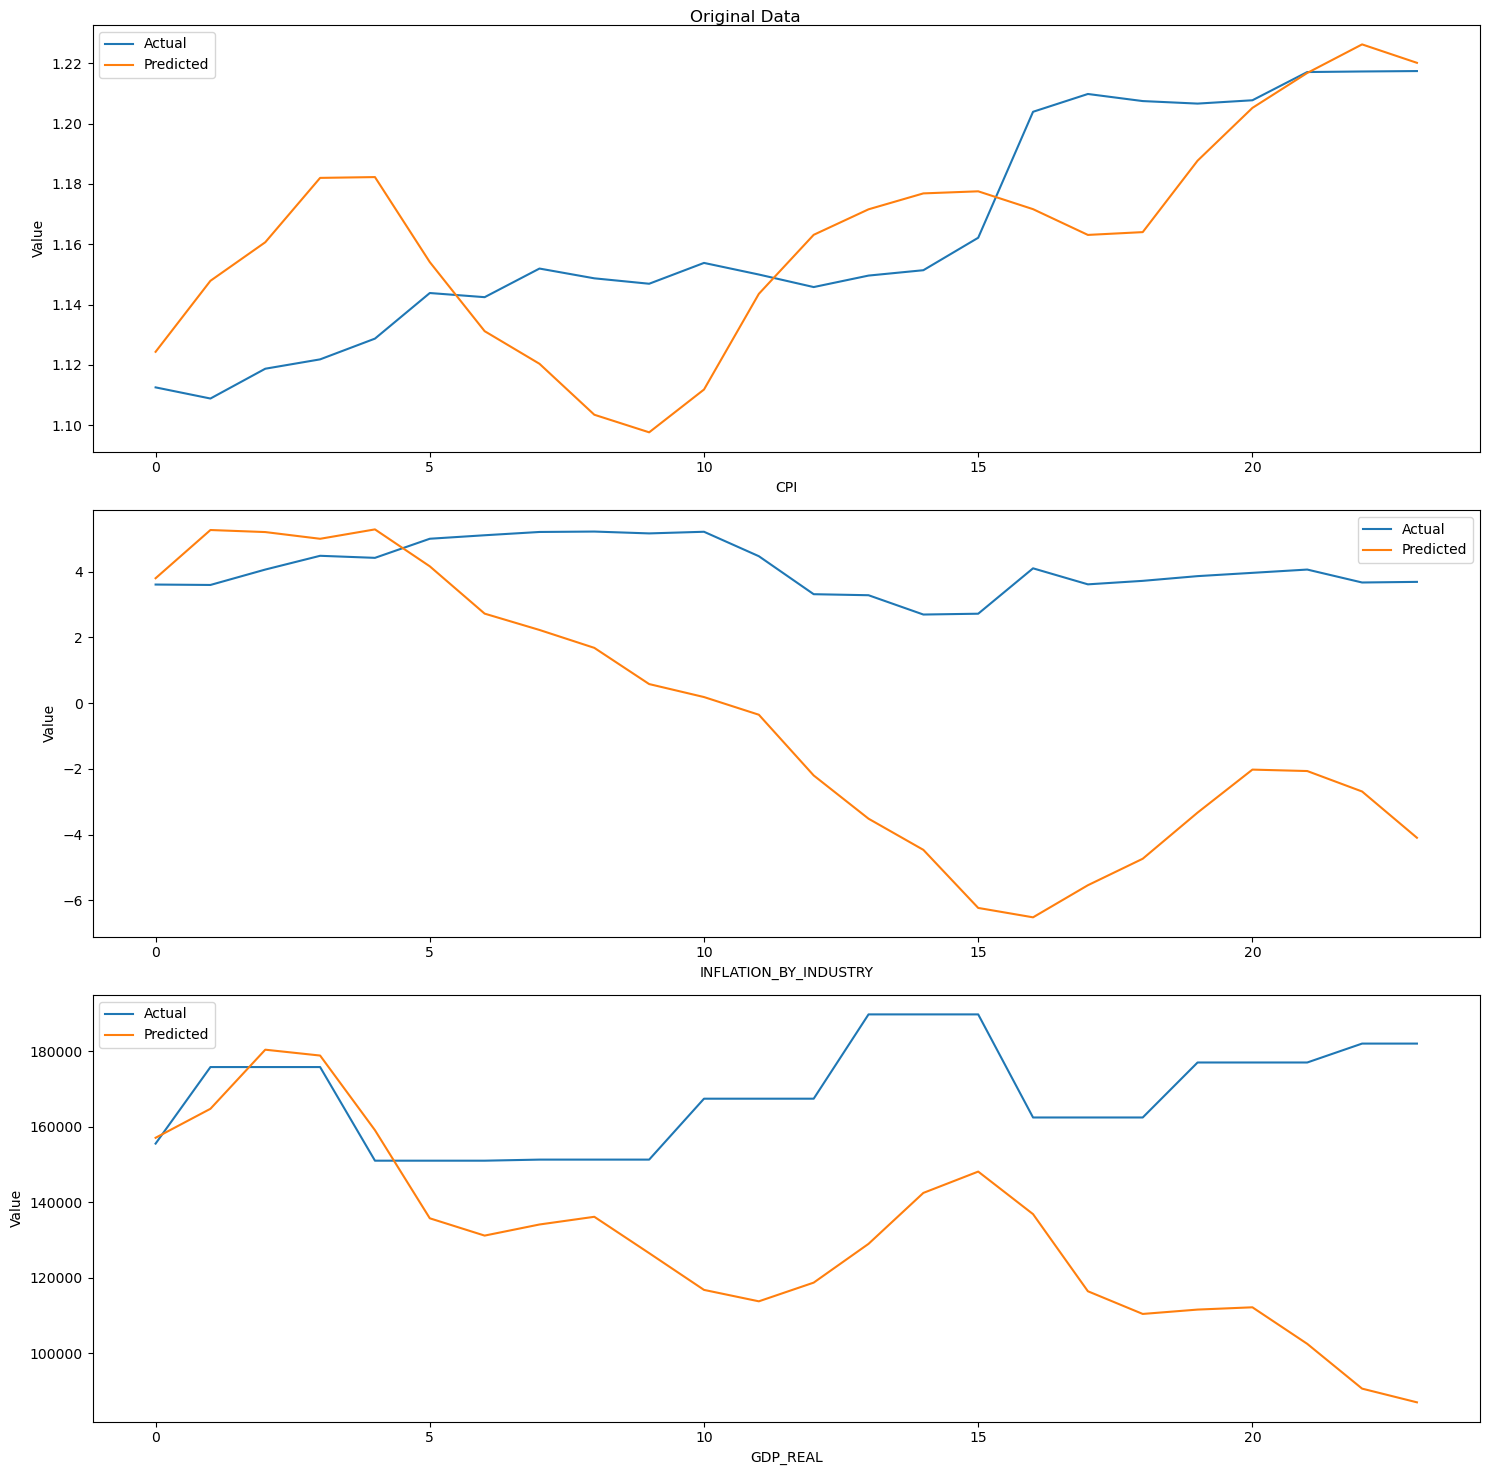

In [51]:
plt.figure(figsize=(15, 15))
for i in range(no_columns):
    plt.subplot(no_columns, 1, i+1)
    plt.plot(actual_original[:, i], label='Actual')
    plt.plot(unscaled_VAR[:, i], label='Predicted')
    plt.title('')
    plt.xlabel(f'{scaled_test.columns[i]}')
    plt.ylabel('Value')
    plt.legend()
plt.suptitle('Original Data')
plt.tight_layout()
plt.show()

# Test with all lag

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 1
Column CPI - MSE: 0.042264860520399655, RMSE: 0.2055841932649484, MAE: 0.17715963291209982
Column INFLATION_BY_INDUSTRY - MSE: 21.50734630476792, RMSE: 4.637601352506263, MAE: 4.401740989444503
Column GDP_REAL - MSE: 1249340054.6216319, RMSE: 35346.00479009801, MAE: 27722.17221727132


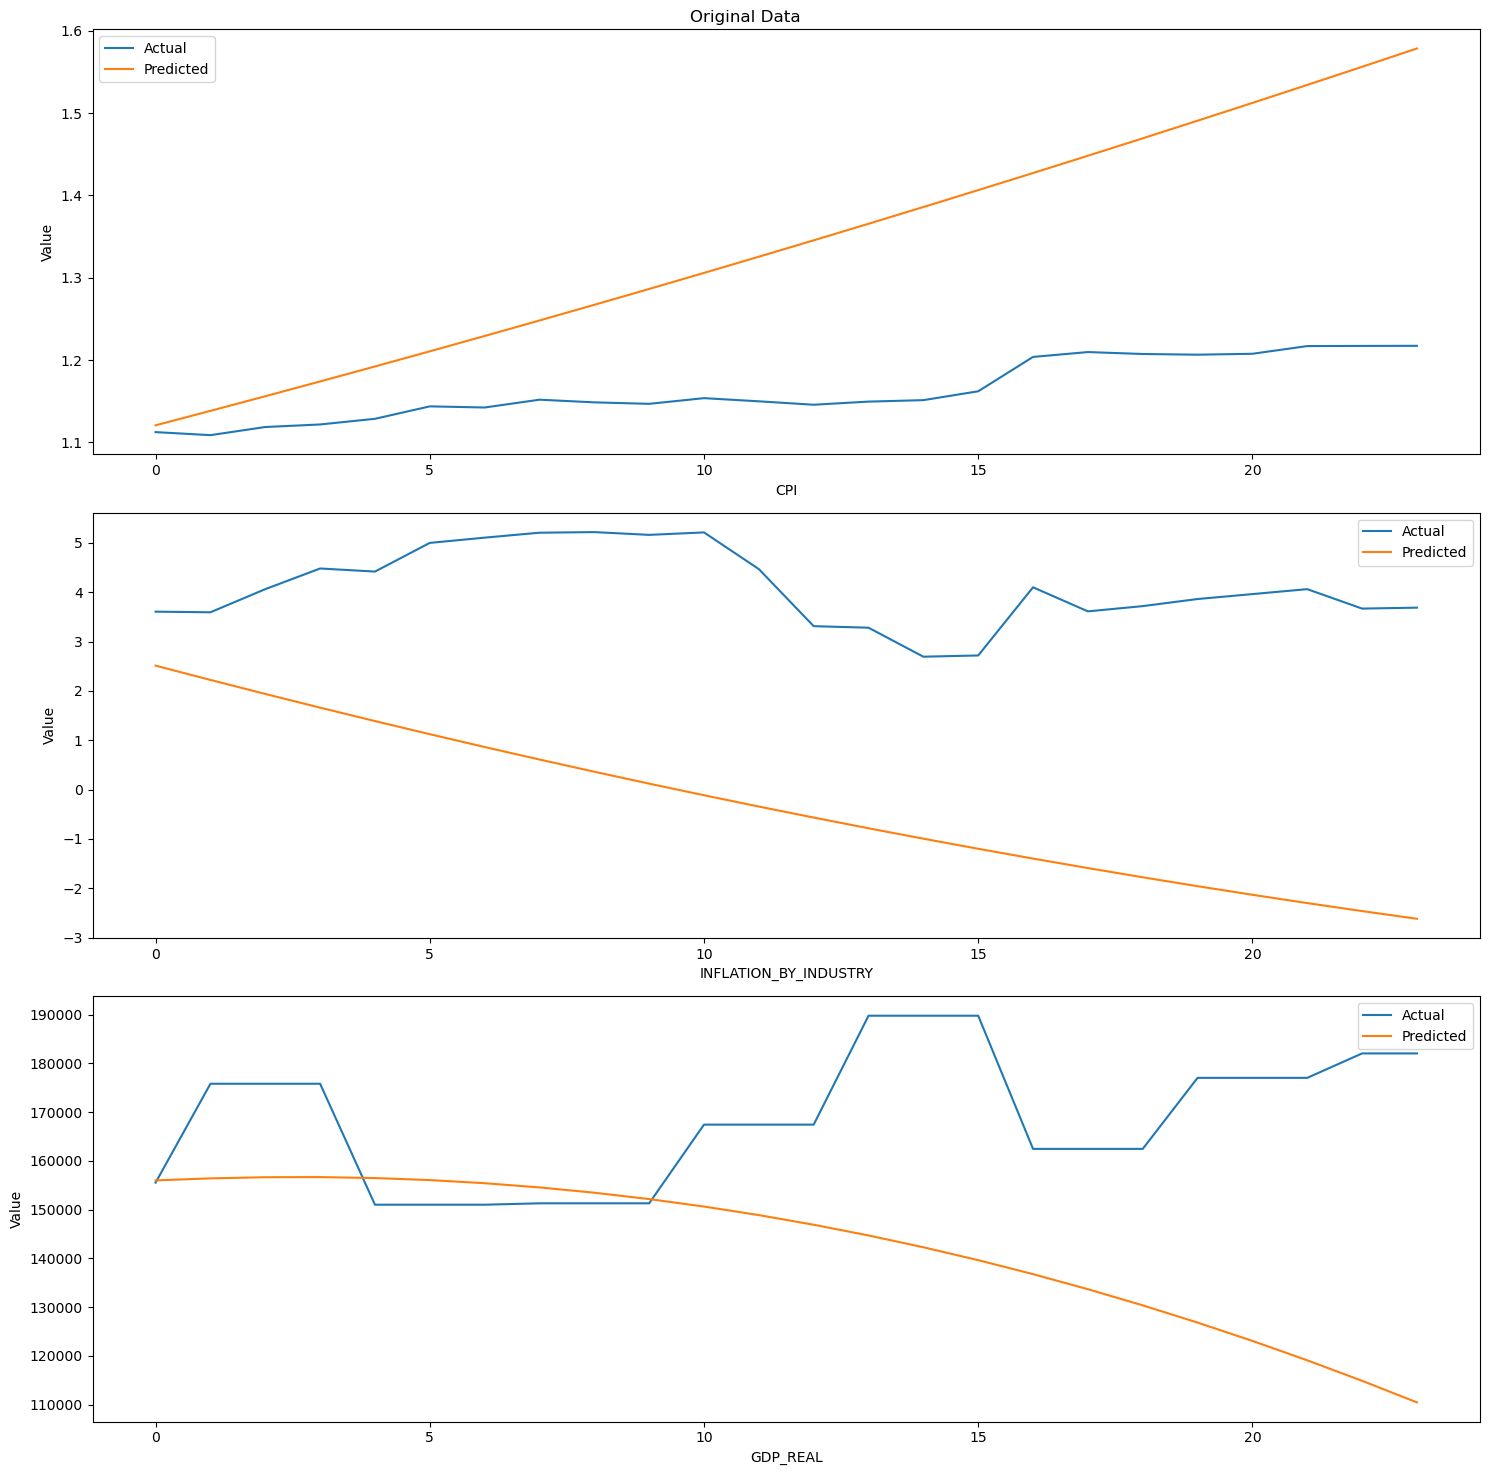

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 2
Column CPI - MSE: 0.008005920956404686, RMSE: 0.08947581213045616, MAE: 0.077029734006357
Column INFLATION_BY_INDUSTRY - MSE: 130.90280129359837, RMSE: 11.441276209129748, MAE: 10.46251176811631
Column GDP_REAL - MSE: 11161066554.78692, RMSE: 105645.94906945992, MAE: 91335.98785459461


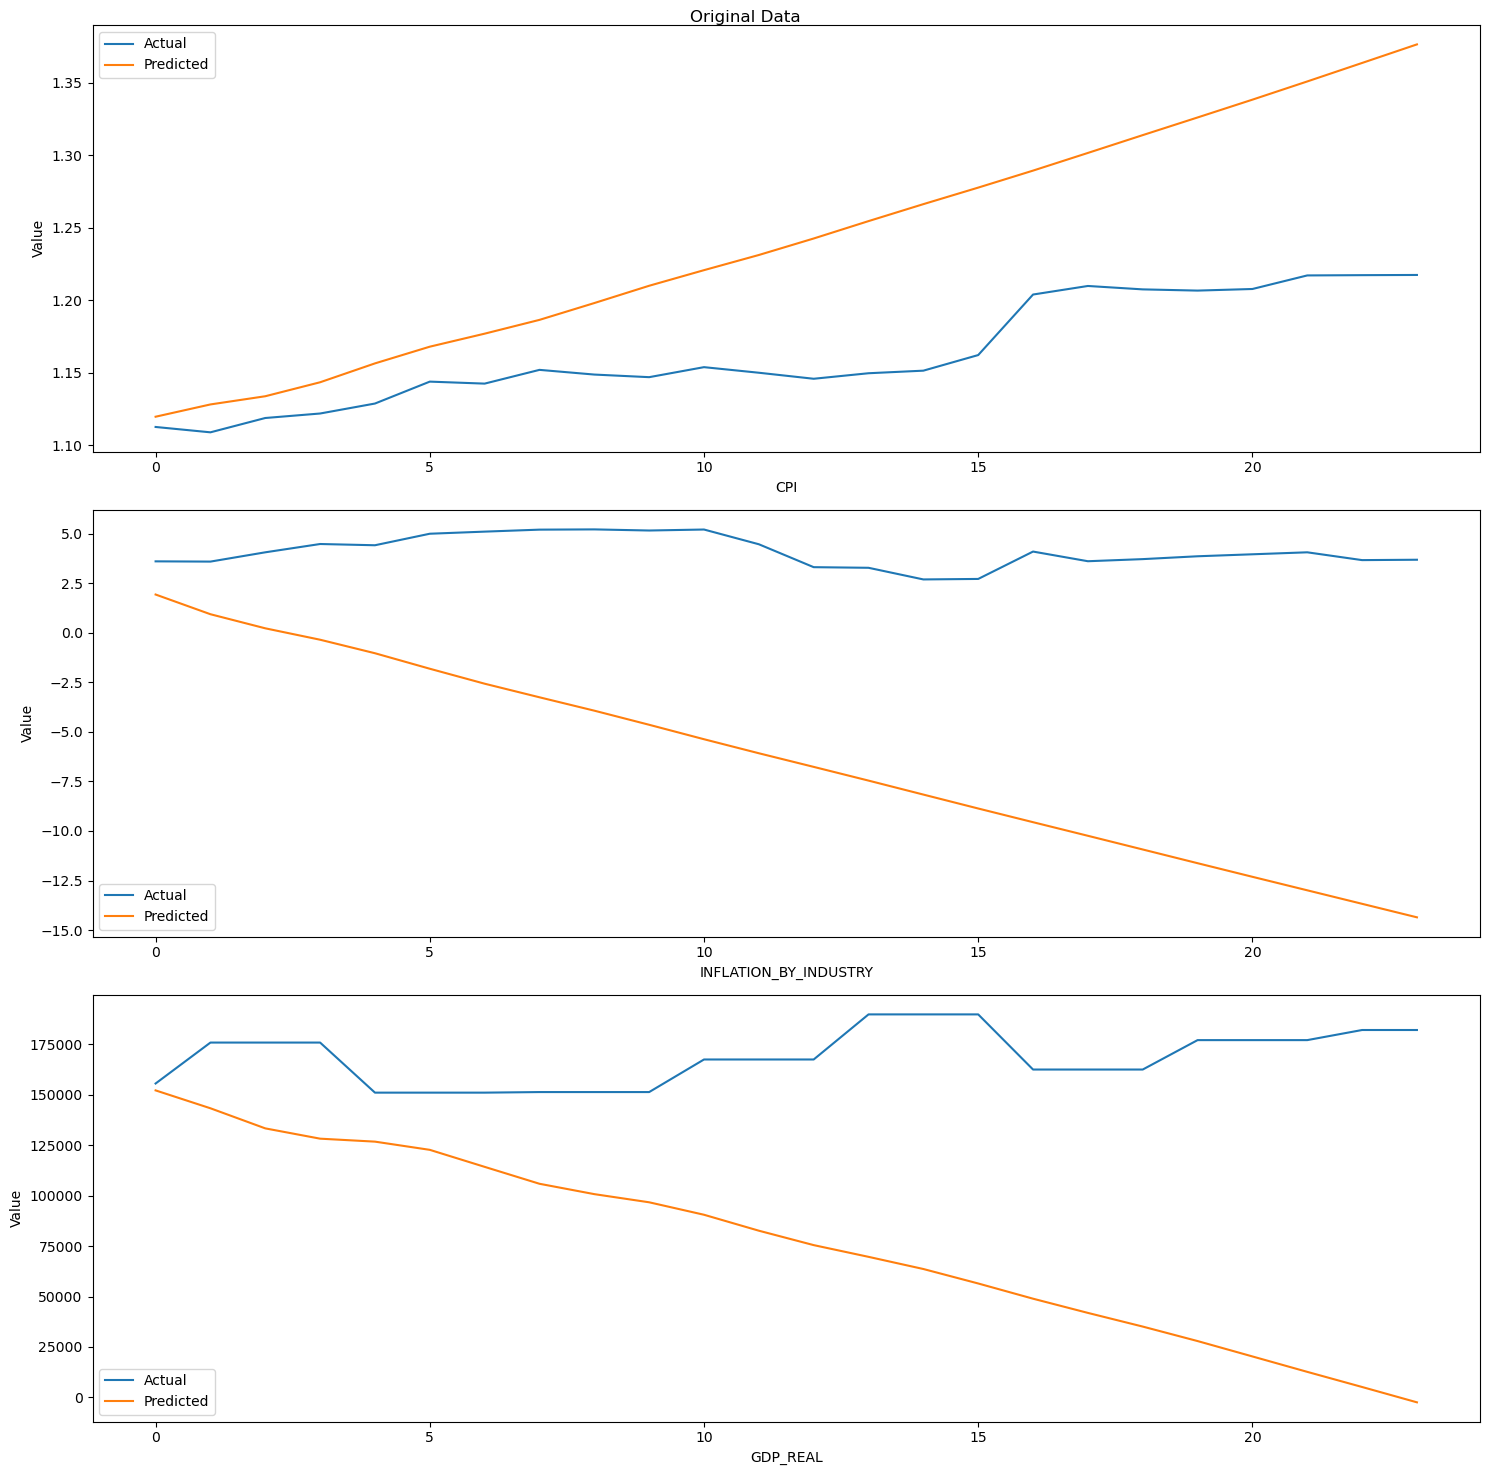

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 3
Column CPI - MSE: 0.03148923605654261, RMSE: 0.17745206692665658, MAE: 0.15482270777969545
Column INFLATION_BY_INDUSTRY - MSE: 200.9034493908191, RMSE: 14.17404139230654, MAE: 12.76721246285287
Column GDP_REAL - MSE: 10204696739.970953, RMSE: 101018.29903522902, MAE: 88218.13475623944


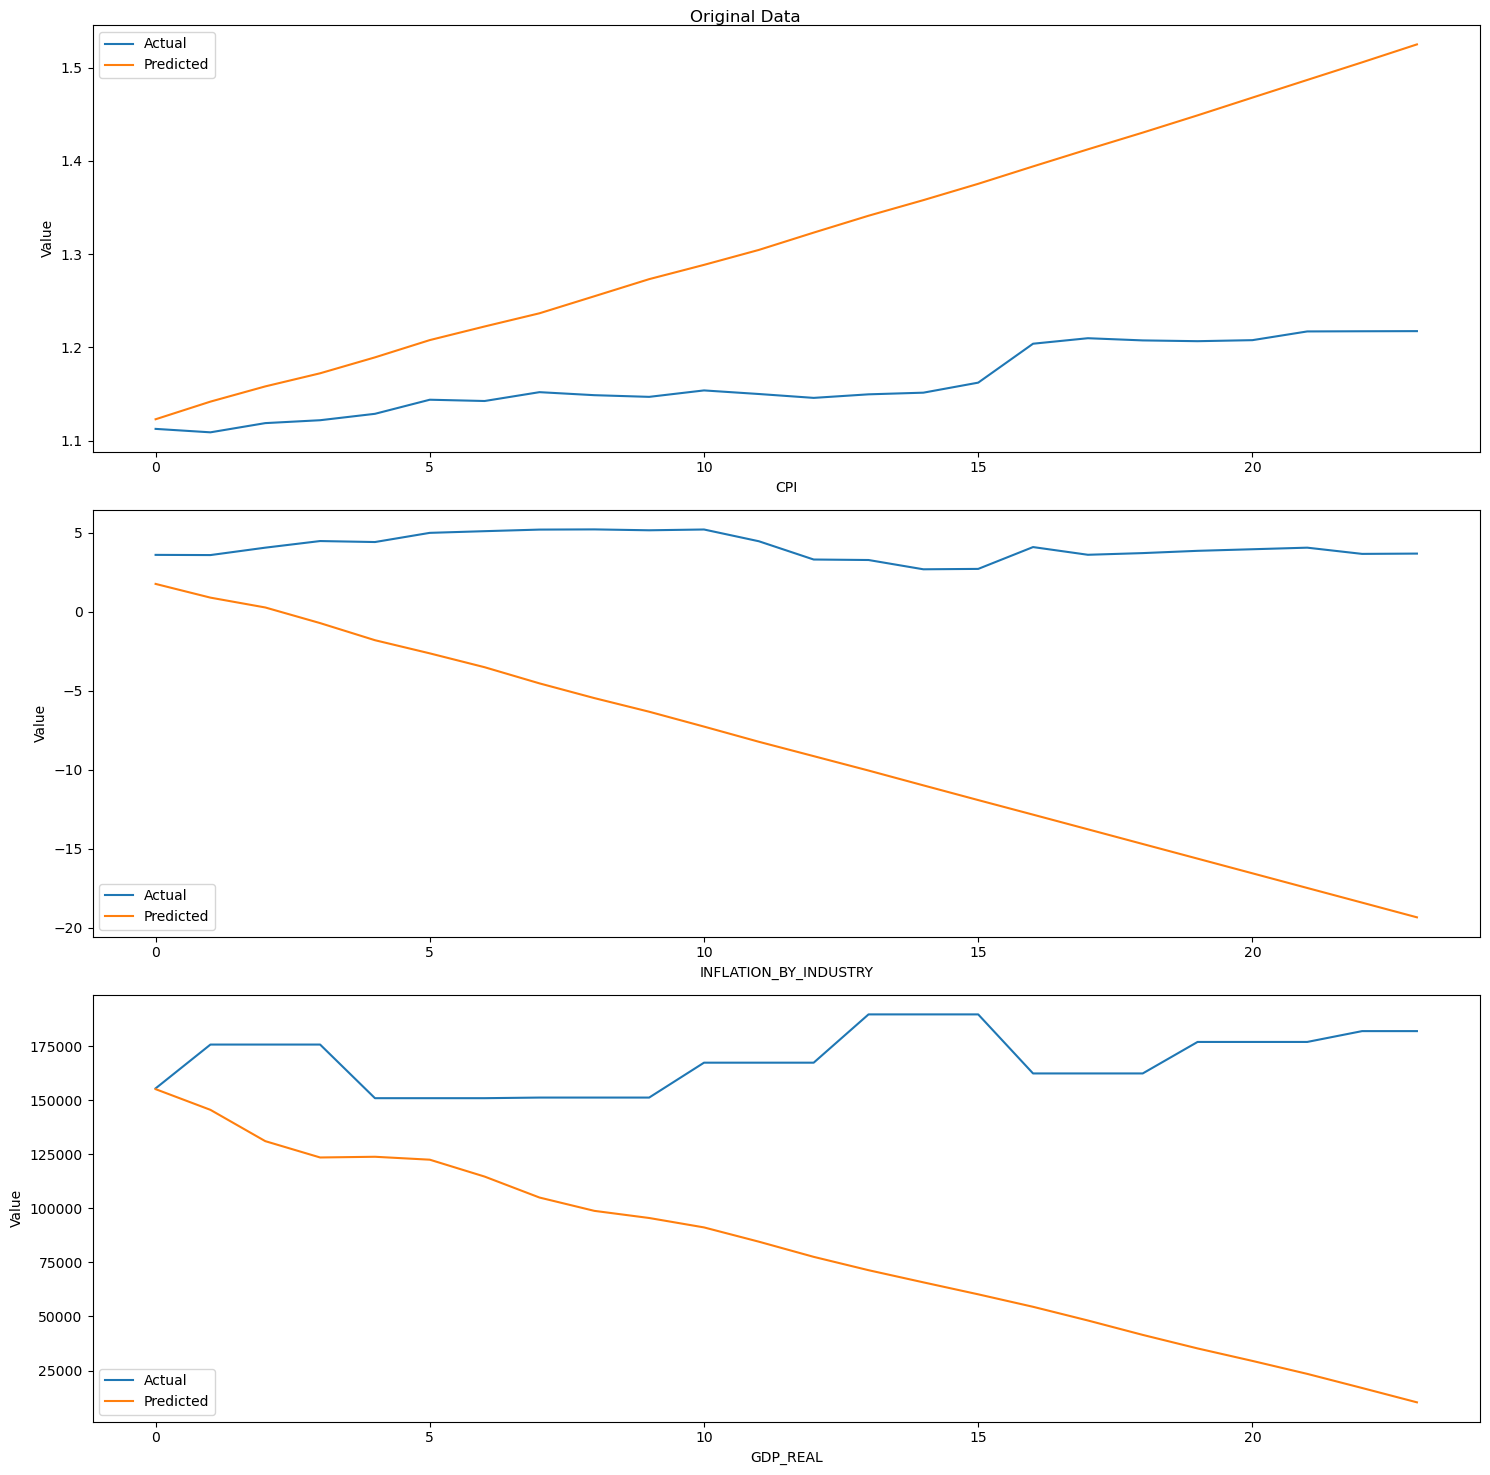

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 4
Column CPI - MSE: 0.008764236054592927, RMSE: 0.09361749865592932, MAE: 0.08230204917490233
Column INFLATION_BY_INDUSTRY - MSE: 405.2051805139528, RMSE: 20.12970890286178, MAE: 18.058867561873395
Column GDP_REAL - MSE: 14134258121.704329, RMSE: 118887.58607064208, MAE: 104926.42969575839


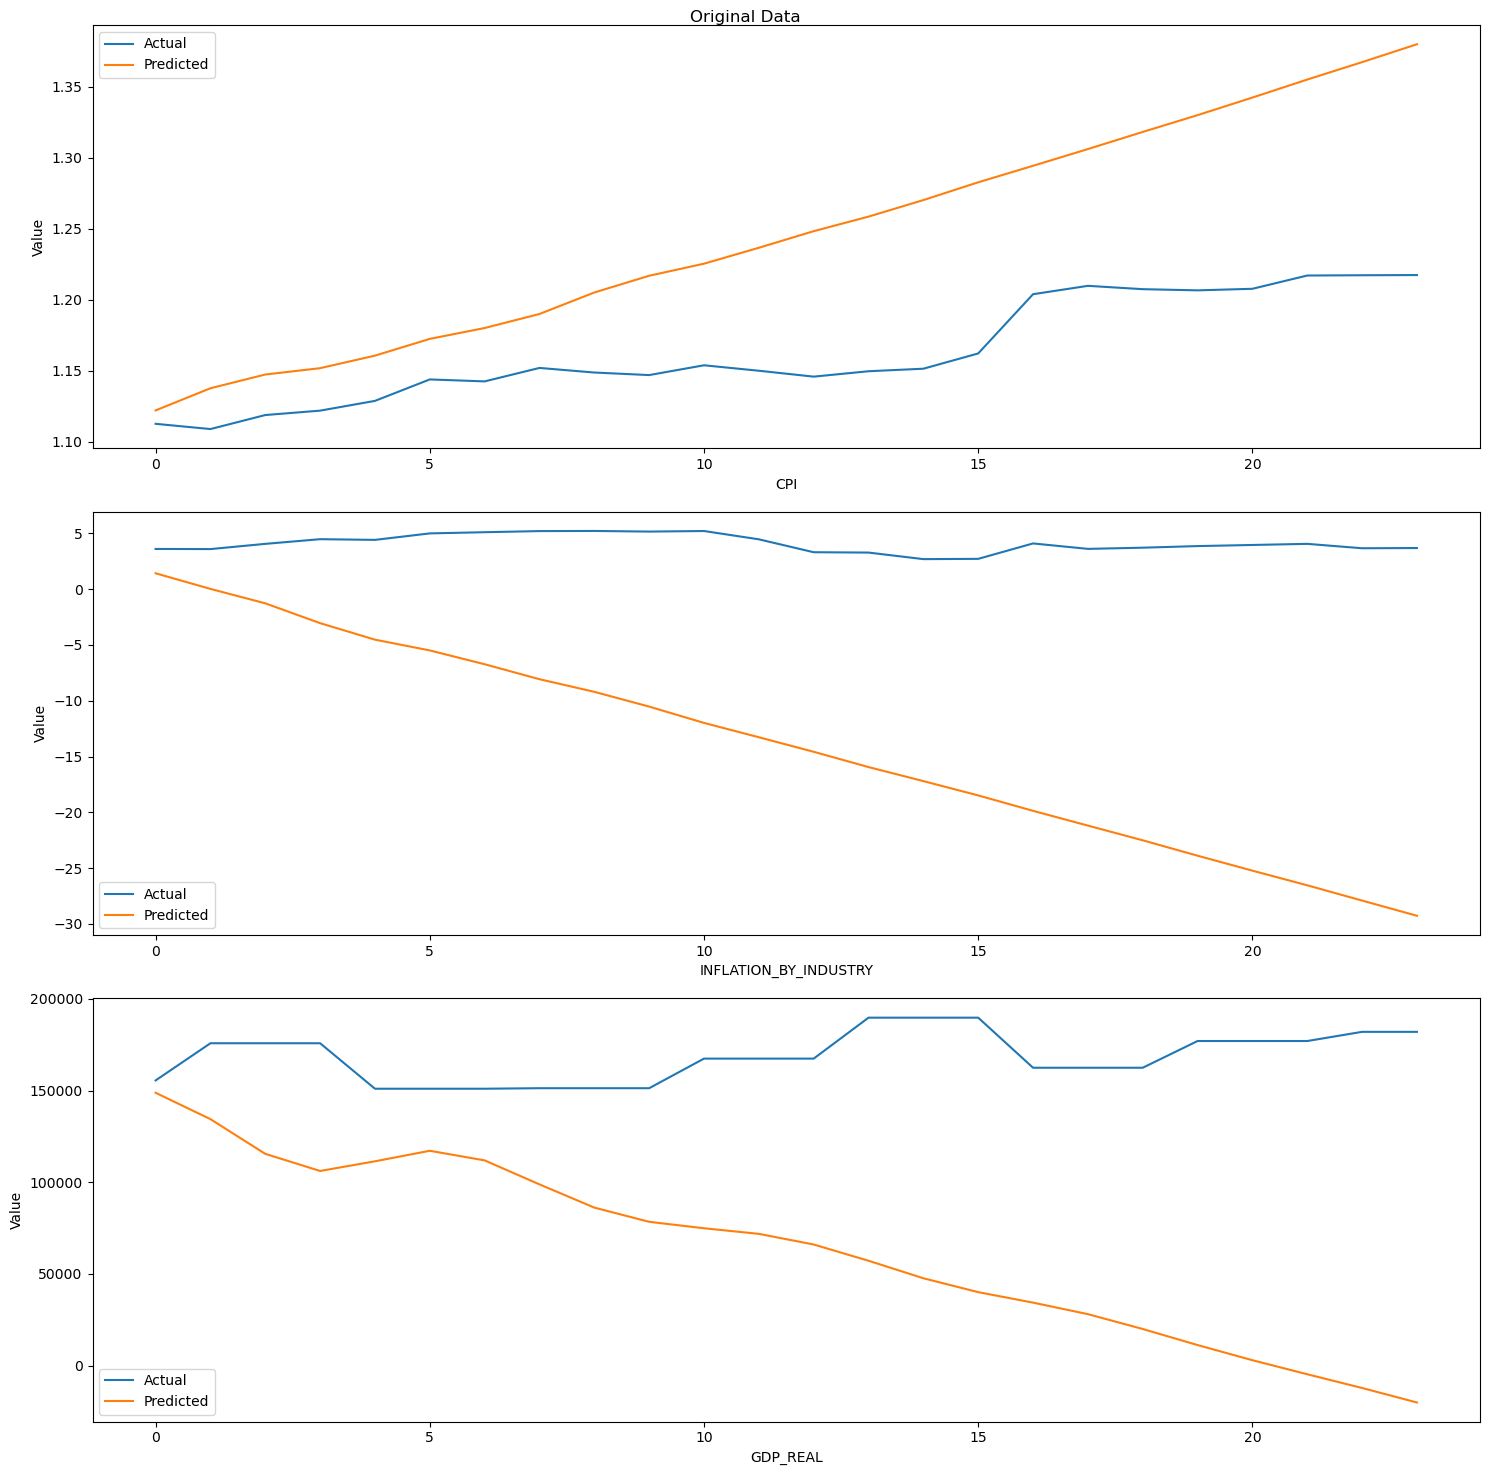

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 5
Column CPI - MSE: 0.005820772235755861, RMSE: 0.07629398558048898, MAE: 0.06788172290907118
Column INFLATION_BY_INDUSTRY - MSE: 437.9818394924436, RMSE: 20.928015660650765, MAE: 18.73951851961566
Column GDP_REAL - MSE: 12158093280.696768, RMSE: 110263.74418047289, MAE: 98806.7963502652


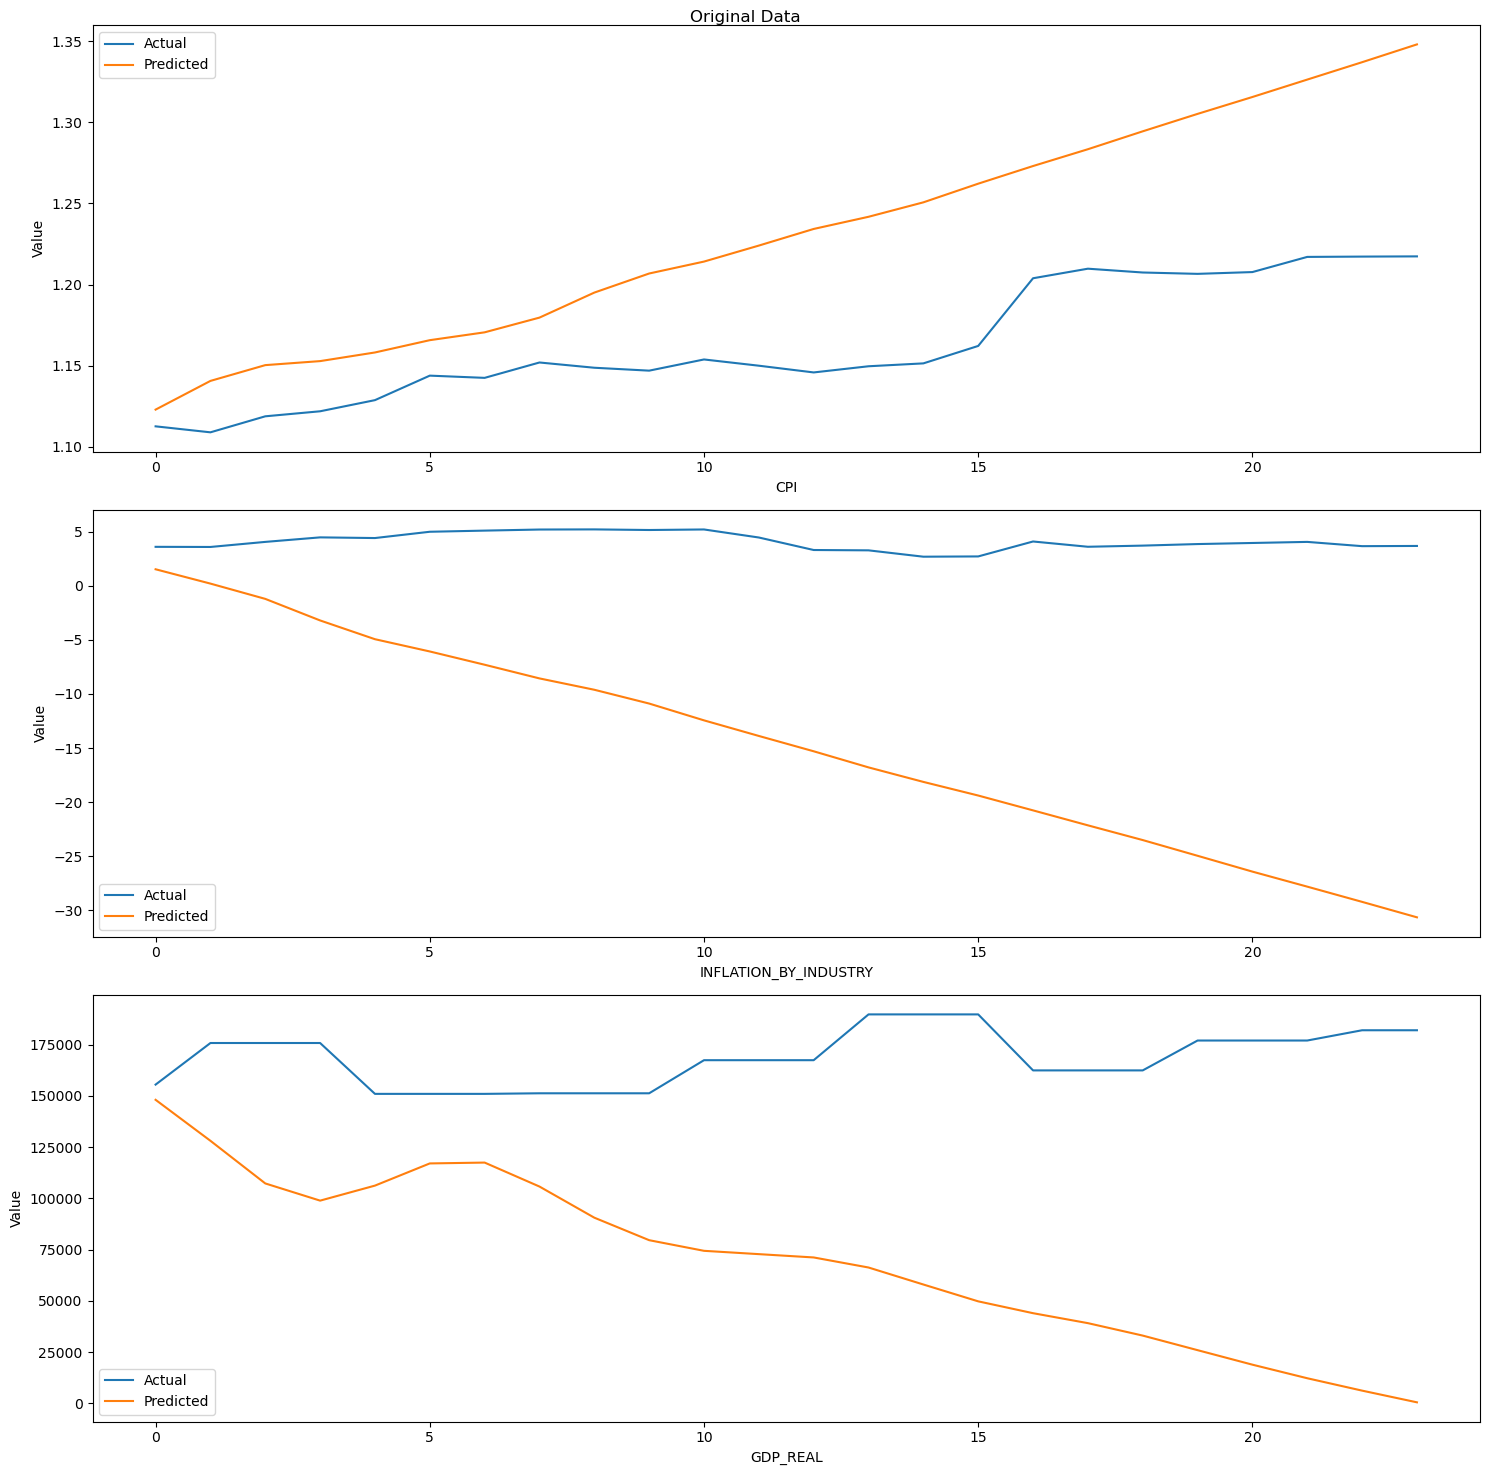

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 6
Column CPI - MSE: 0.010443945451598787, RMSE: 0.10219562344640198, MAE: 0.09167753023064369
Column INFLATION_BY_INDUSTRY - MSE: 412.67838976723004, RMSE: 20.314487189373747, MAE: 18.193575119954314
Column GDP_REAL - MSE: 35686162464.59608, RMSE: 188907.8147261147, MAE: 169809.57369539246


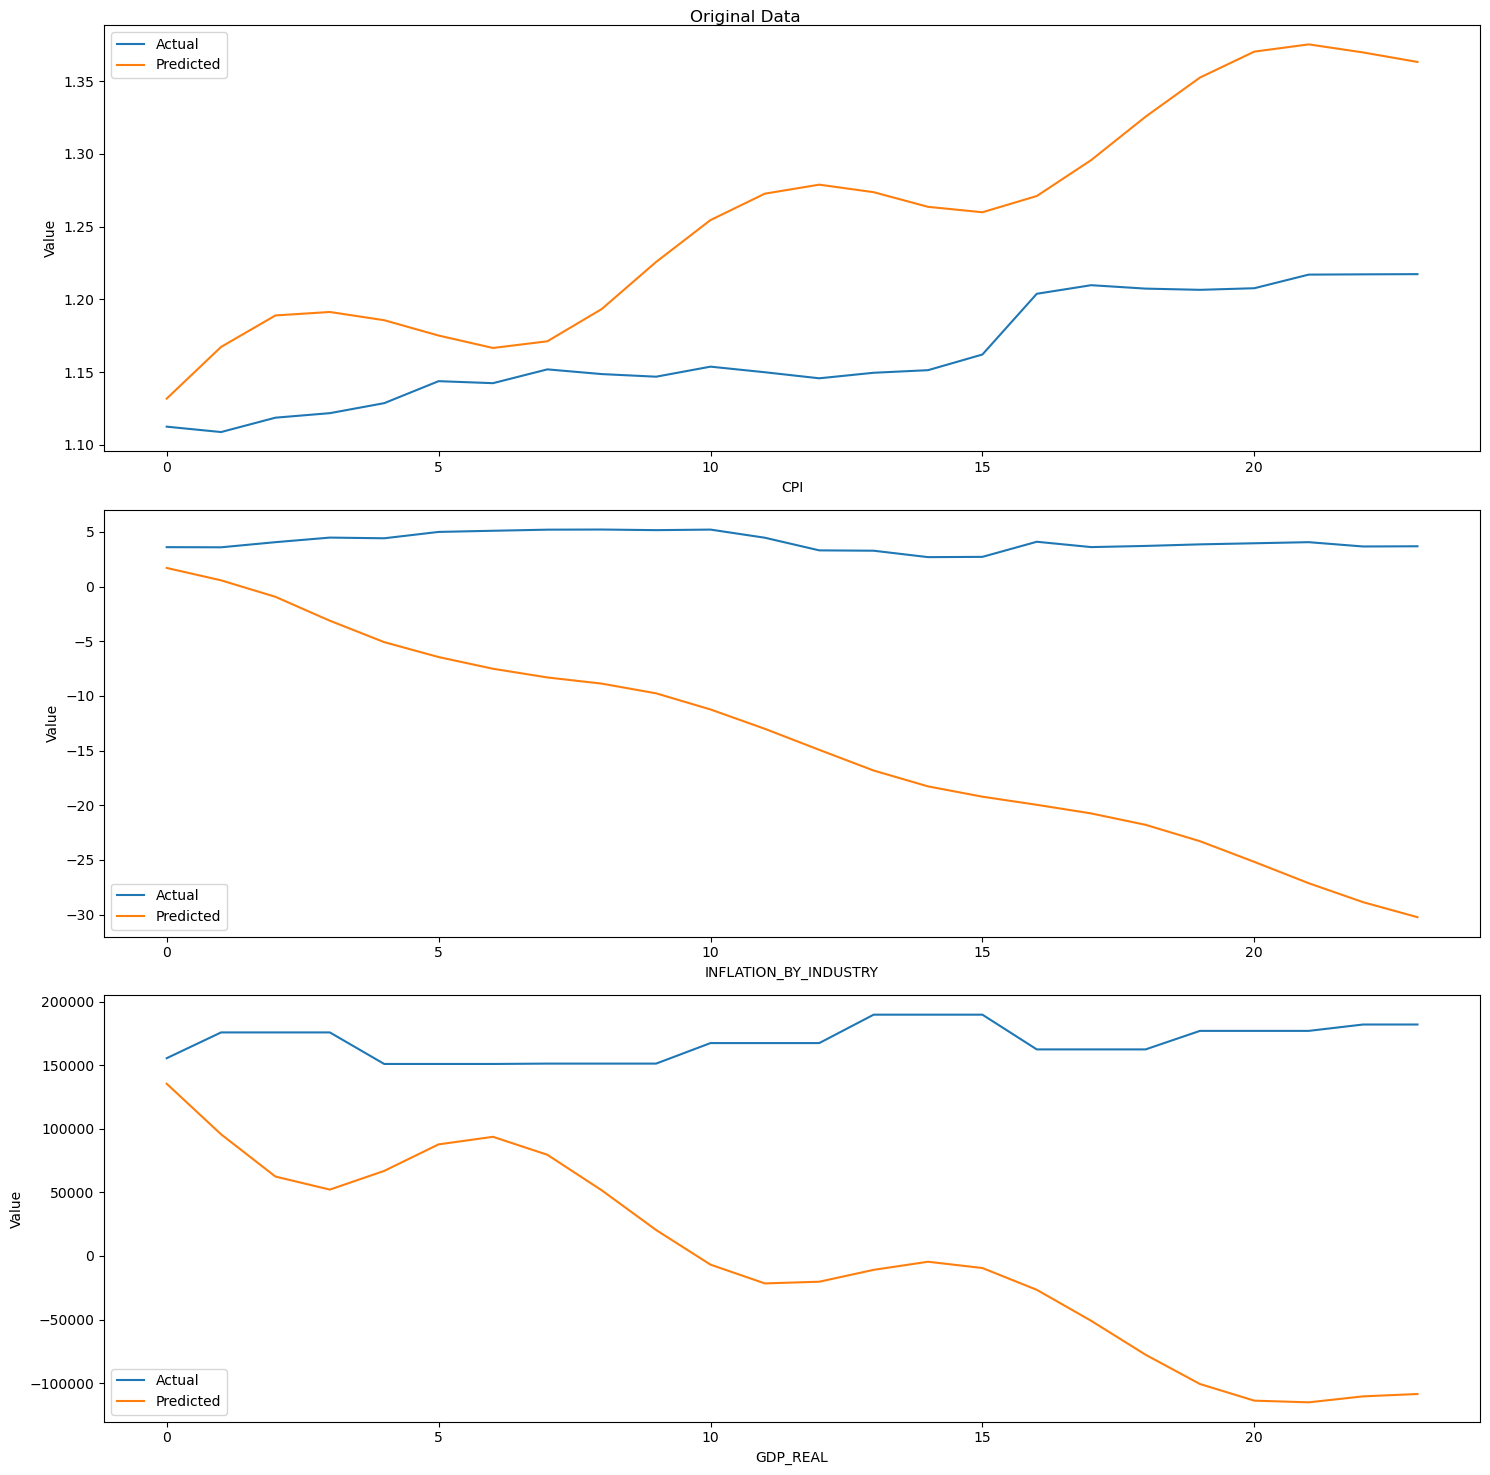

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 7
Column CPI - MSE: 0.009904844402858293, RMSE: 0.09952308477362573, MAE: 0.08840585997240234
Column INFLATION_BY_INDUSTRY - MSE: 70.0506763203177, RMSE: 8.369628206815264, MAE: 7.374123393581139
Column GDP_REAL - MSE: 10167523038.428783, RMSE: 100834.13627551329, MAE: 89858.75256074178


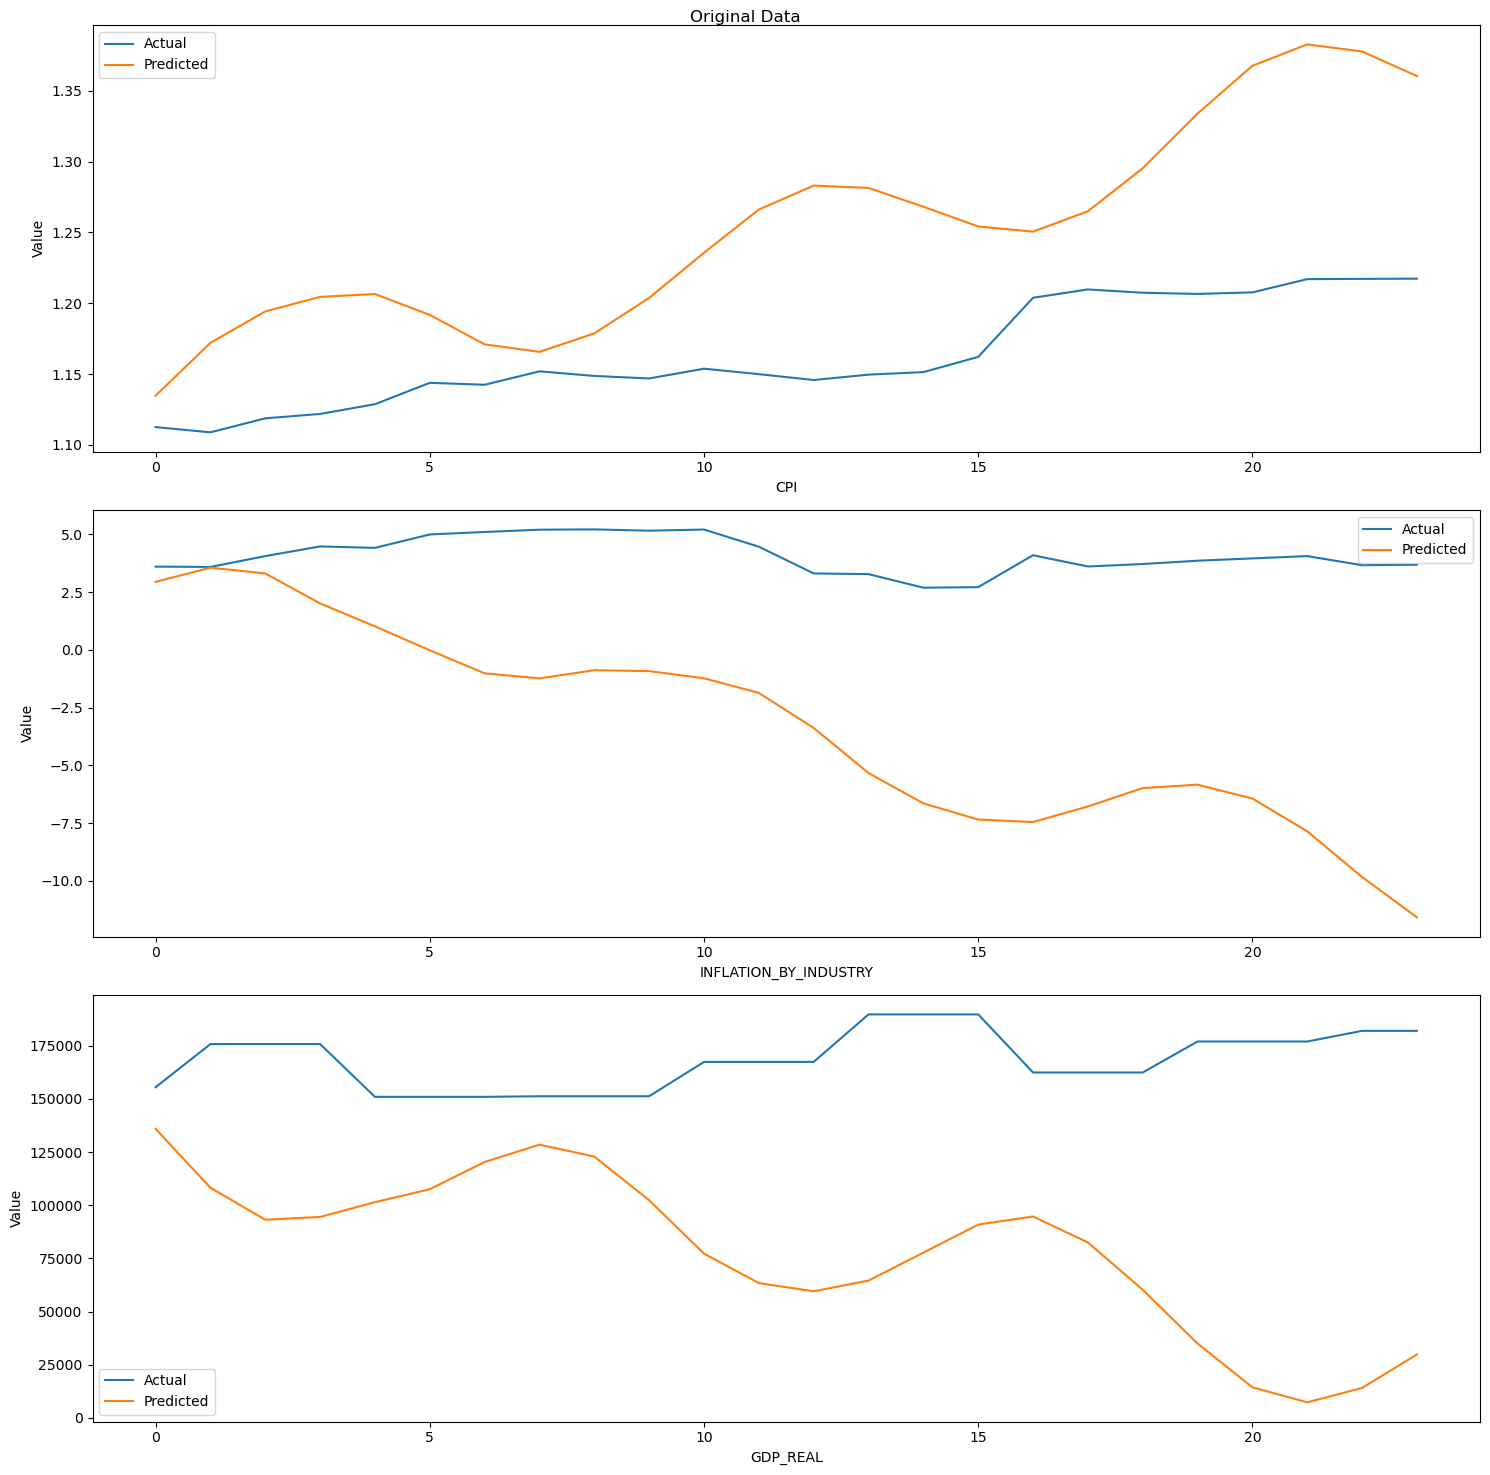

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 8
Column CPI - MSE: 0.006943809152644145, RMSE: 0.08332952149535089, MAE: 0.07232664180008036
Column INFLATION_BY_INDUSTRY - MSE: 91.23781336921202, RMSE: 9.551848688563489, MAE: 8.365385527304456
Column GDP_REAL - MSE: 4395240188.050664, RMSE: 66296.6076662348, MAE: 57993.95751710708


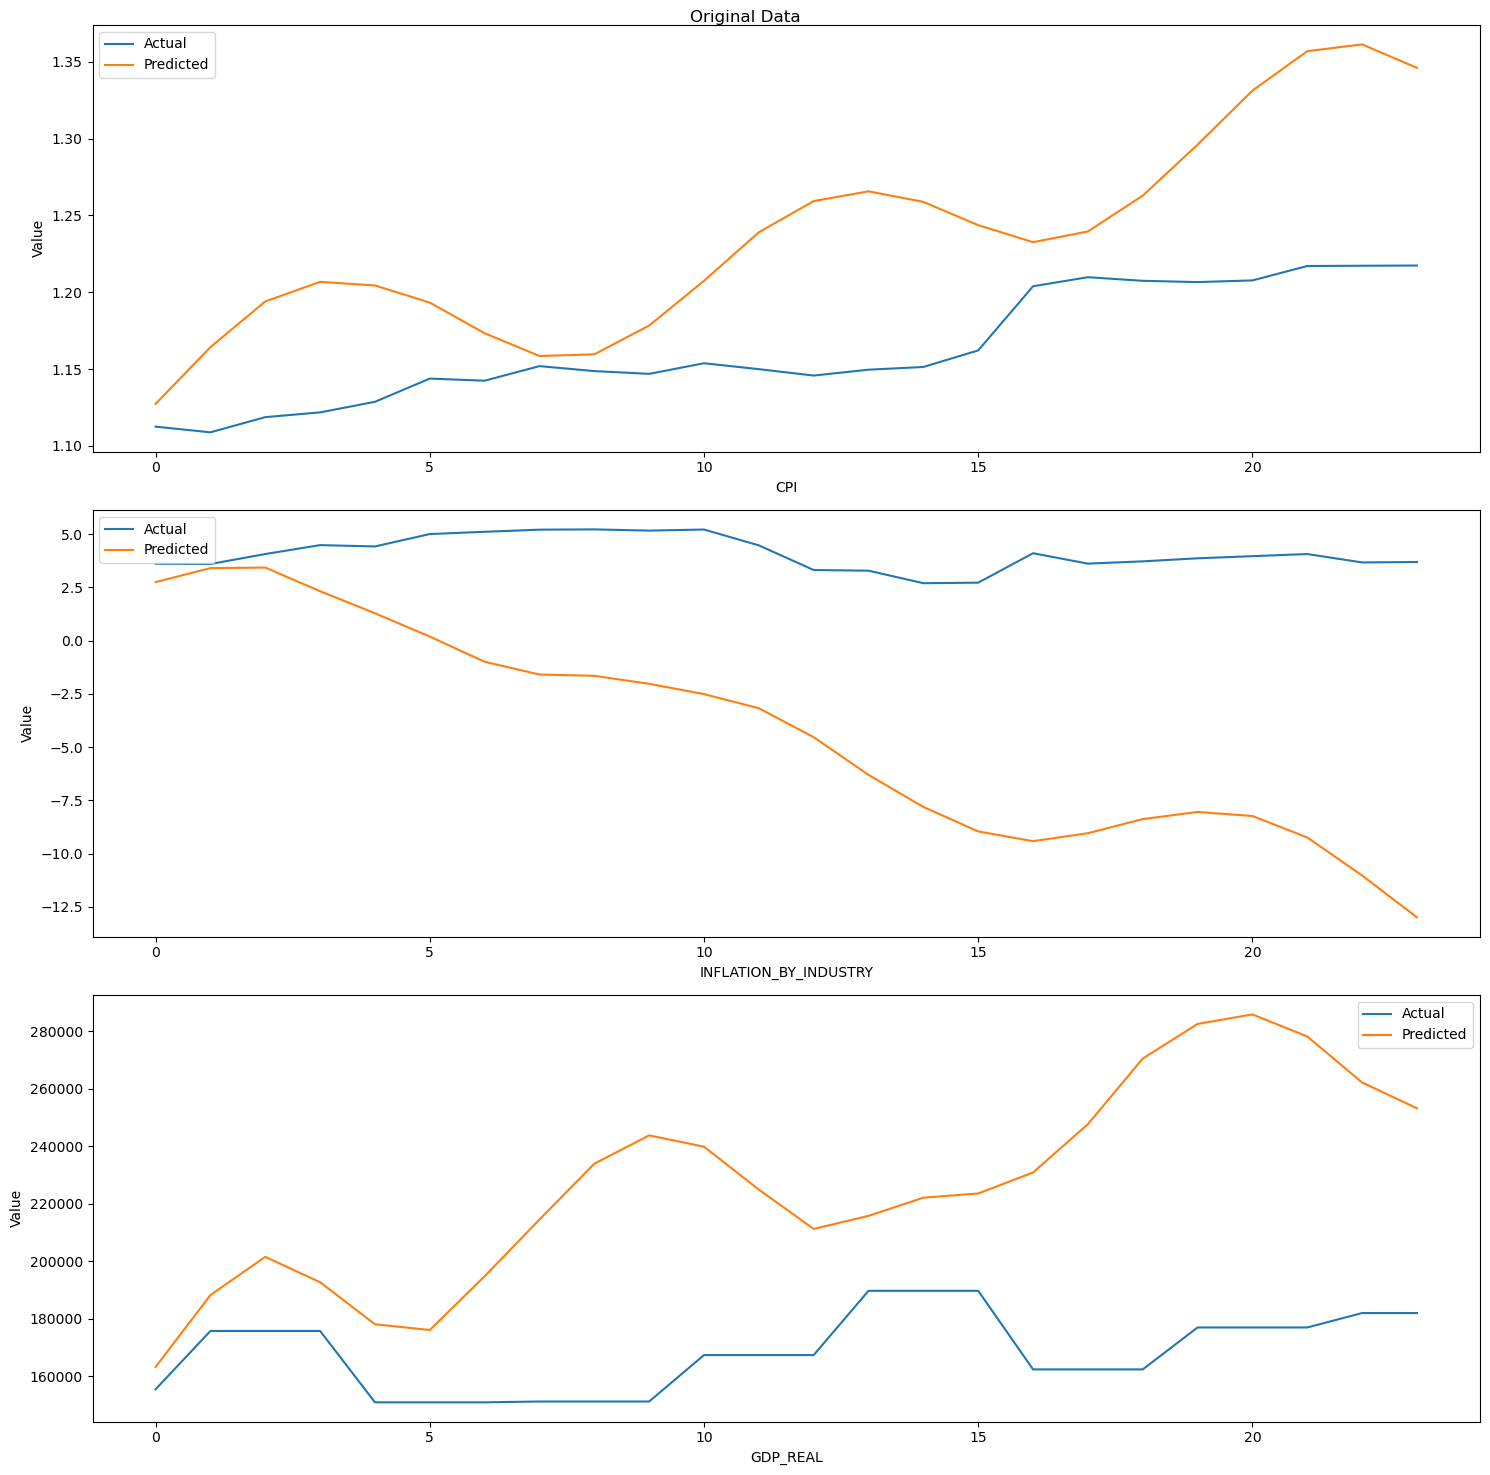

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 9
Column CPI - MSE: 0.002022906143322107, RMSE: 0.044976728908649045, MAE: 0.03818001402409229
Column INFLATION_BY_INDUSTRY - MSE: 64.39285591002209, RMSE: 8.024515929950049, MAE: 6.888439503032281
Column GDP_REAL - MSE: 7266088004.982629, RMSE: 85241.3514966922, MAE: 75085.58248351657


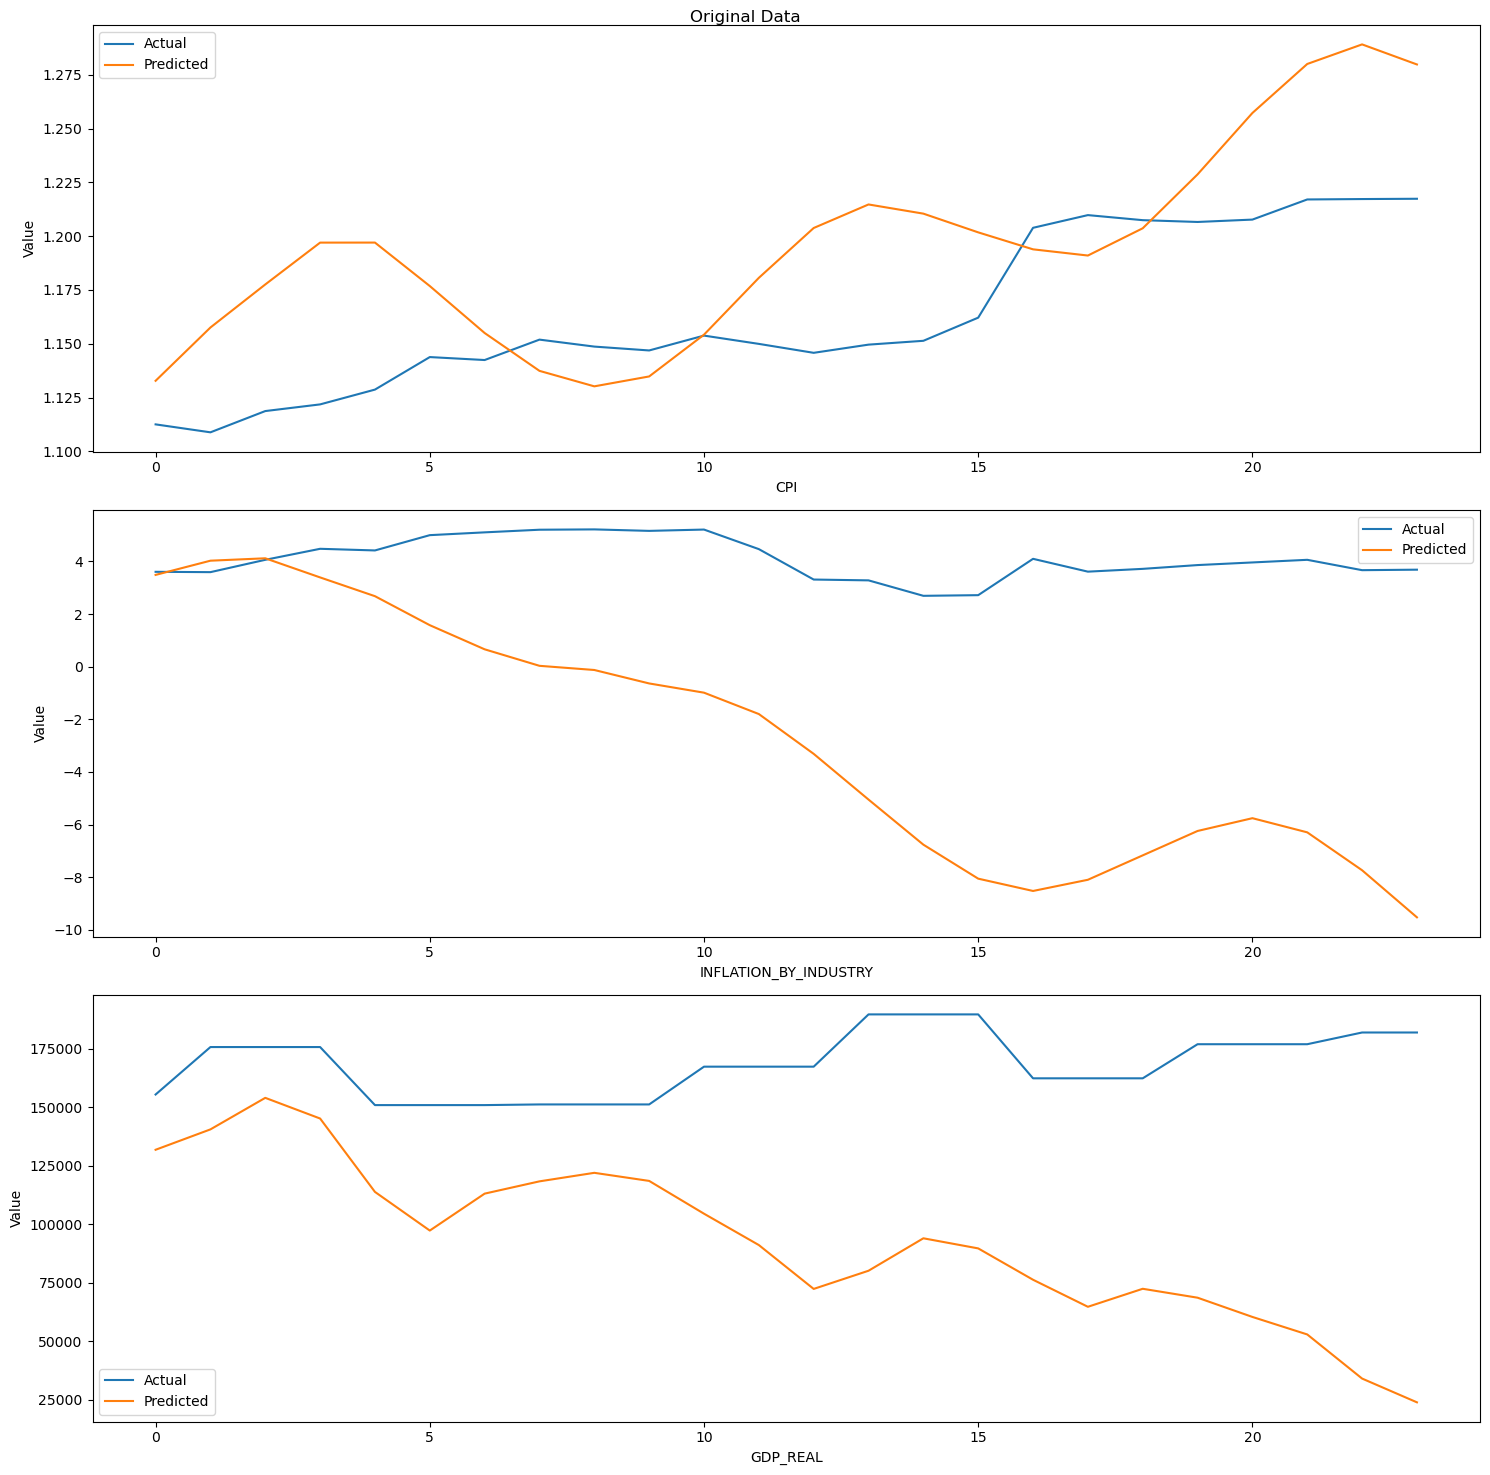

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 10
Column CPI - MSE: 0.0010262577654255641, RMSE: 0.03203525816074477, MAE: 0.026596059328815425
Column INFLATION_BY_INDUSTRY - MSE: 33.54535805434397, RMSE: 5.791835465061483, MAE: 4.945647252471468
Column GDP_REAL - MSE: 2267073681.8321214, RMSE: 47613.79717930635, MAE: 39103.118728167276


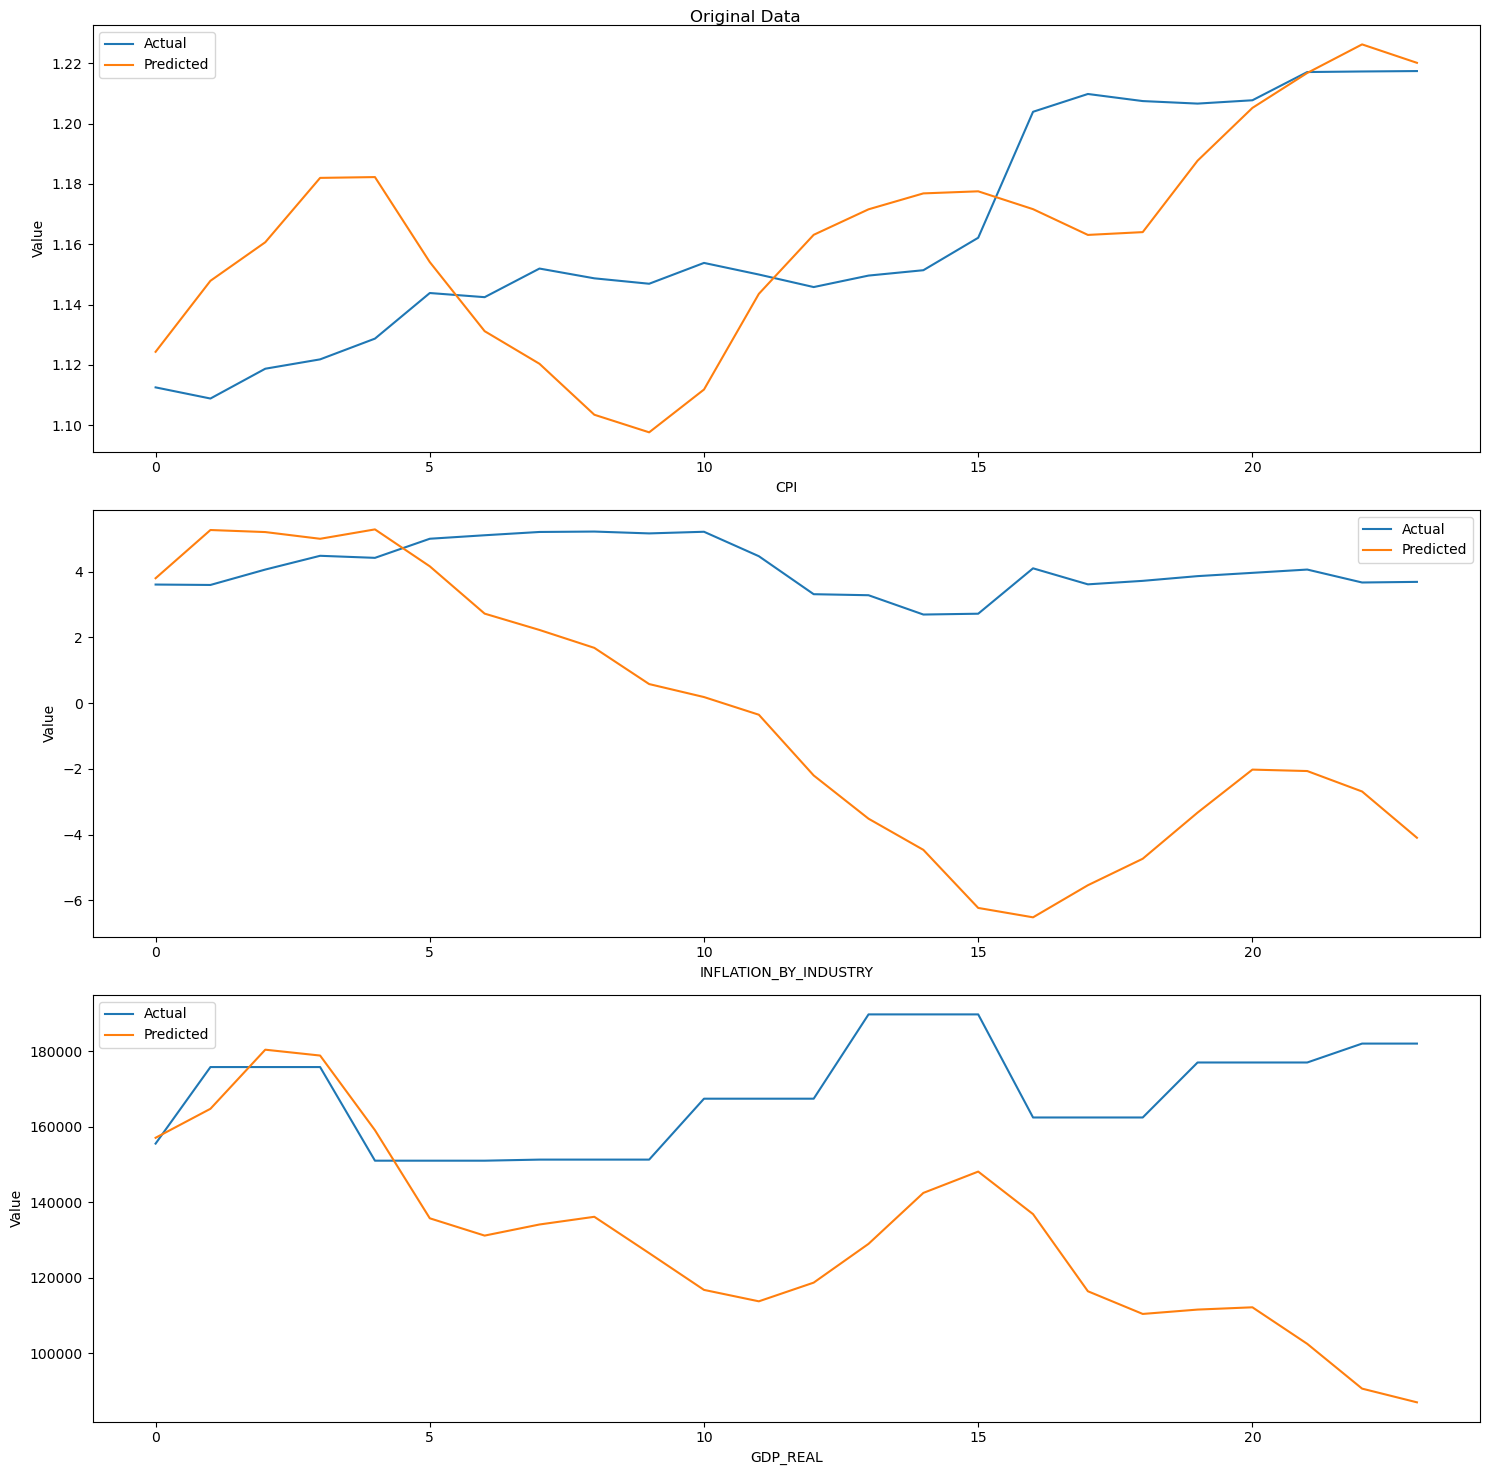

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 11
Column CPI - MSE: 0.03199707631320206, RMSE: 0.1788772660602852, MAE: 0.15200352401420783
Column INFLATION_BY_INDUSTRY - MSE: 222.66523341868574, RMSE: 14.921971499057546, MAE: 13.101661501507033
Column GDP_REAL - MSE: 10218895616.233385, RMSE: 101088.55333930437, MAE: 85992.24772952618


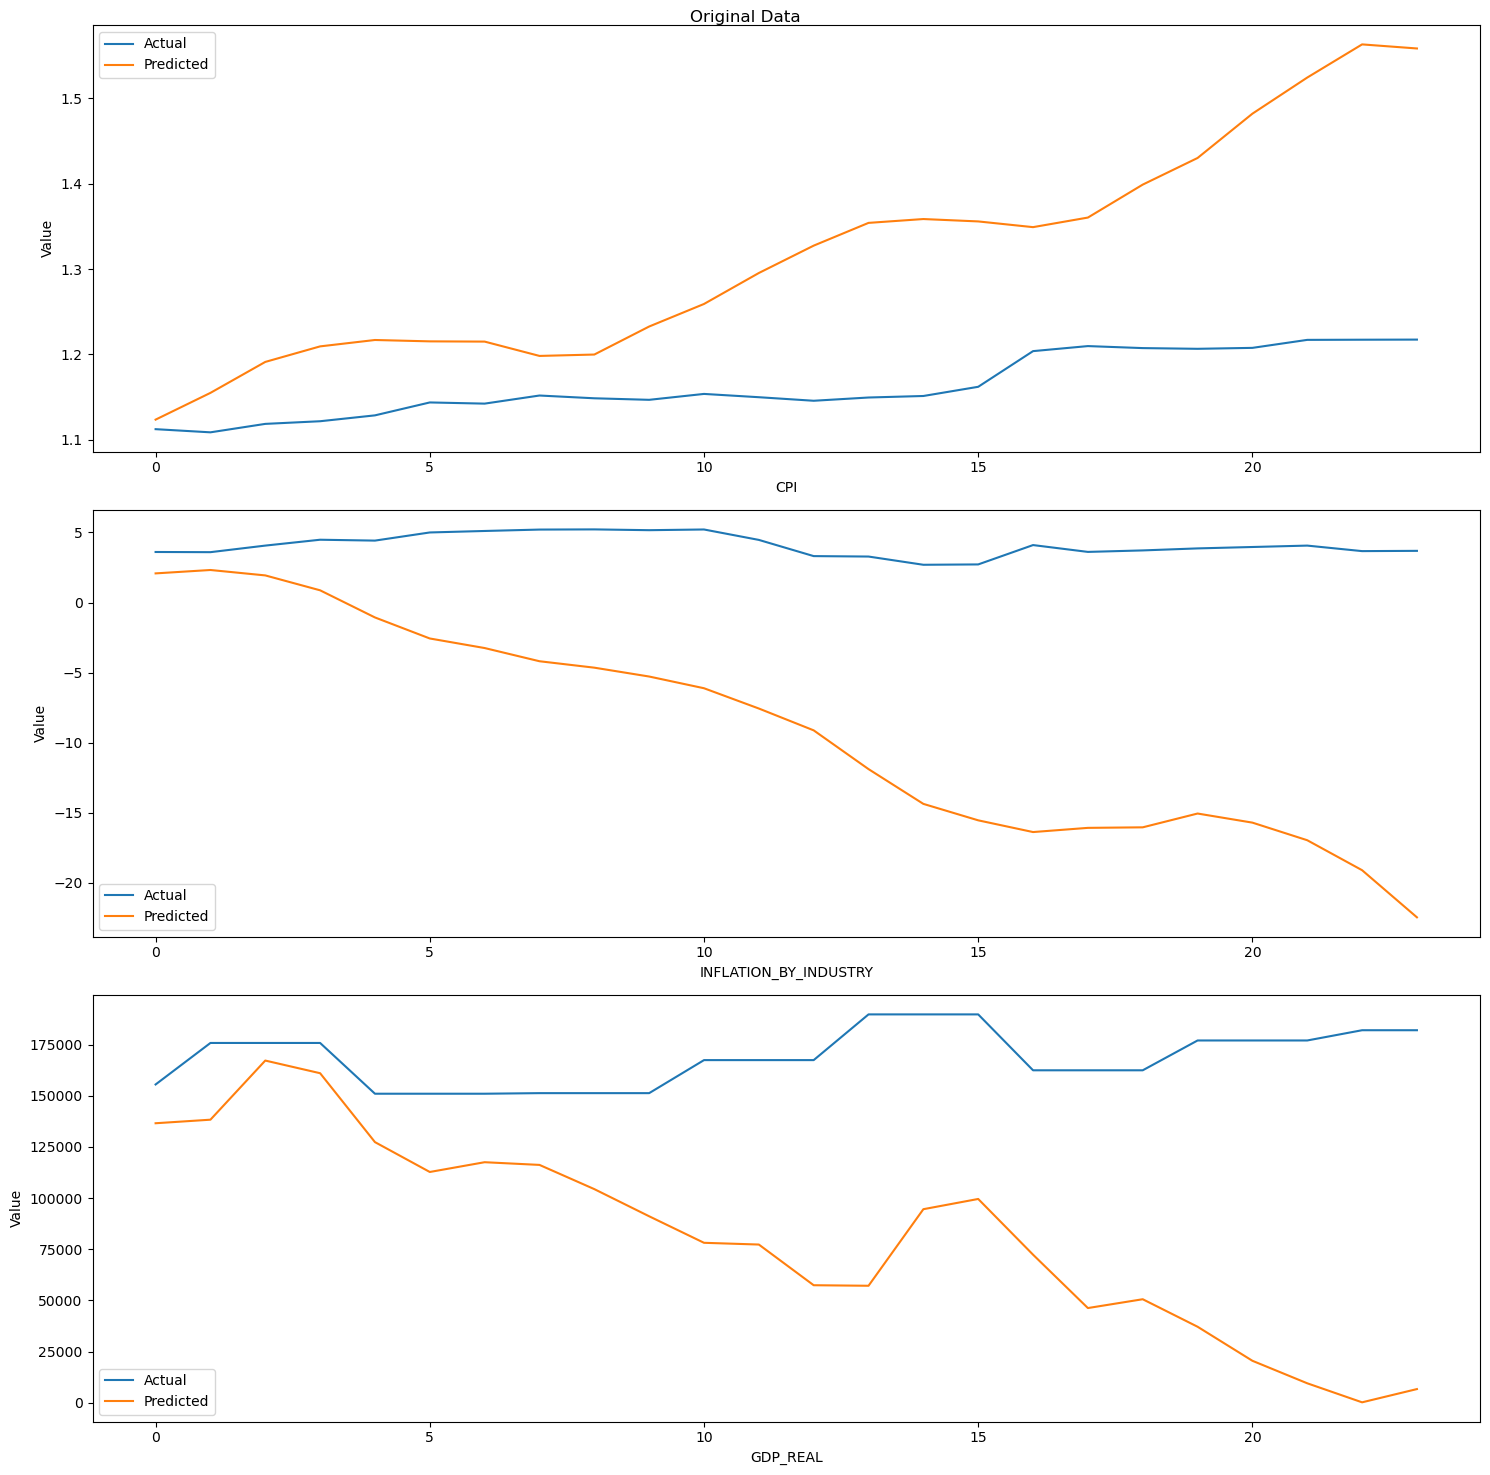

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 12
Column CPI - MSE: 0.00899408333400123, RMSE: 0.09483714111043853, MAE: 0.07870297494286836
Column INFLATION_BY_INDUSTRY - MSE: 171.48962841484186, RMSE: 13.095404858760261, MAE: 10.886374359184332
Column GDP_REAL - MSE: 7560682142.915138, RMSE: 86952.18308308964, MAE: 72968.14861269138


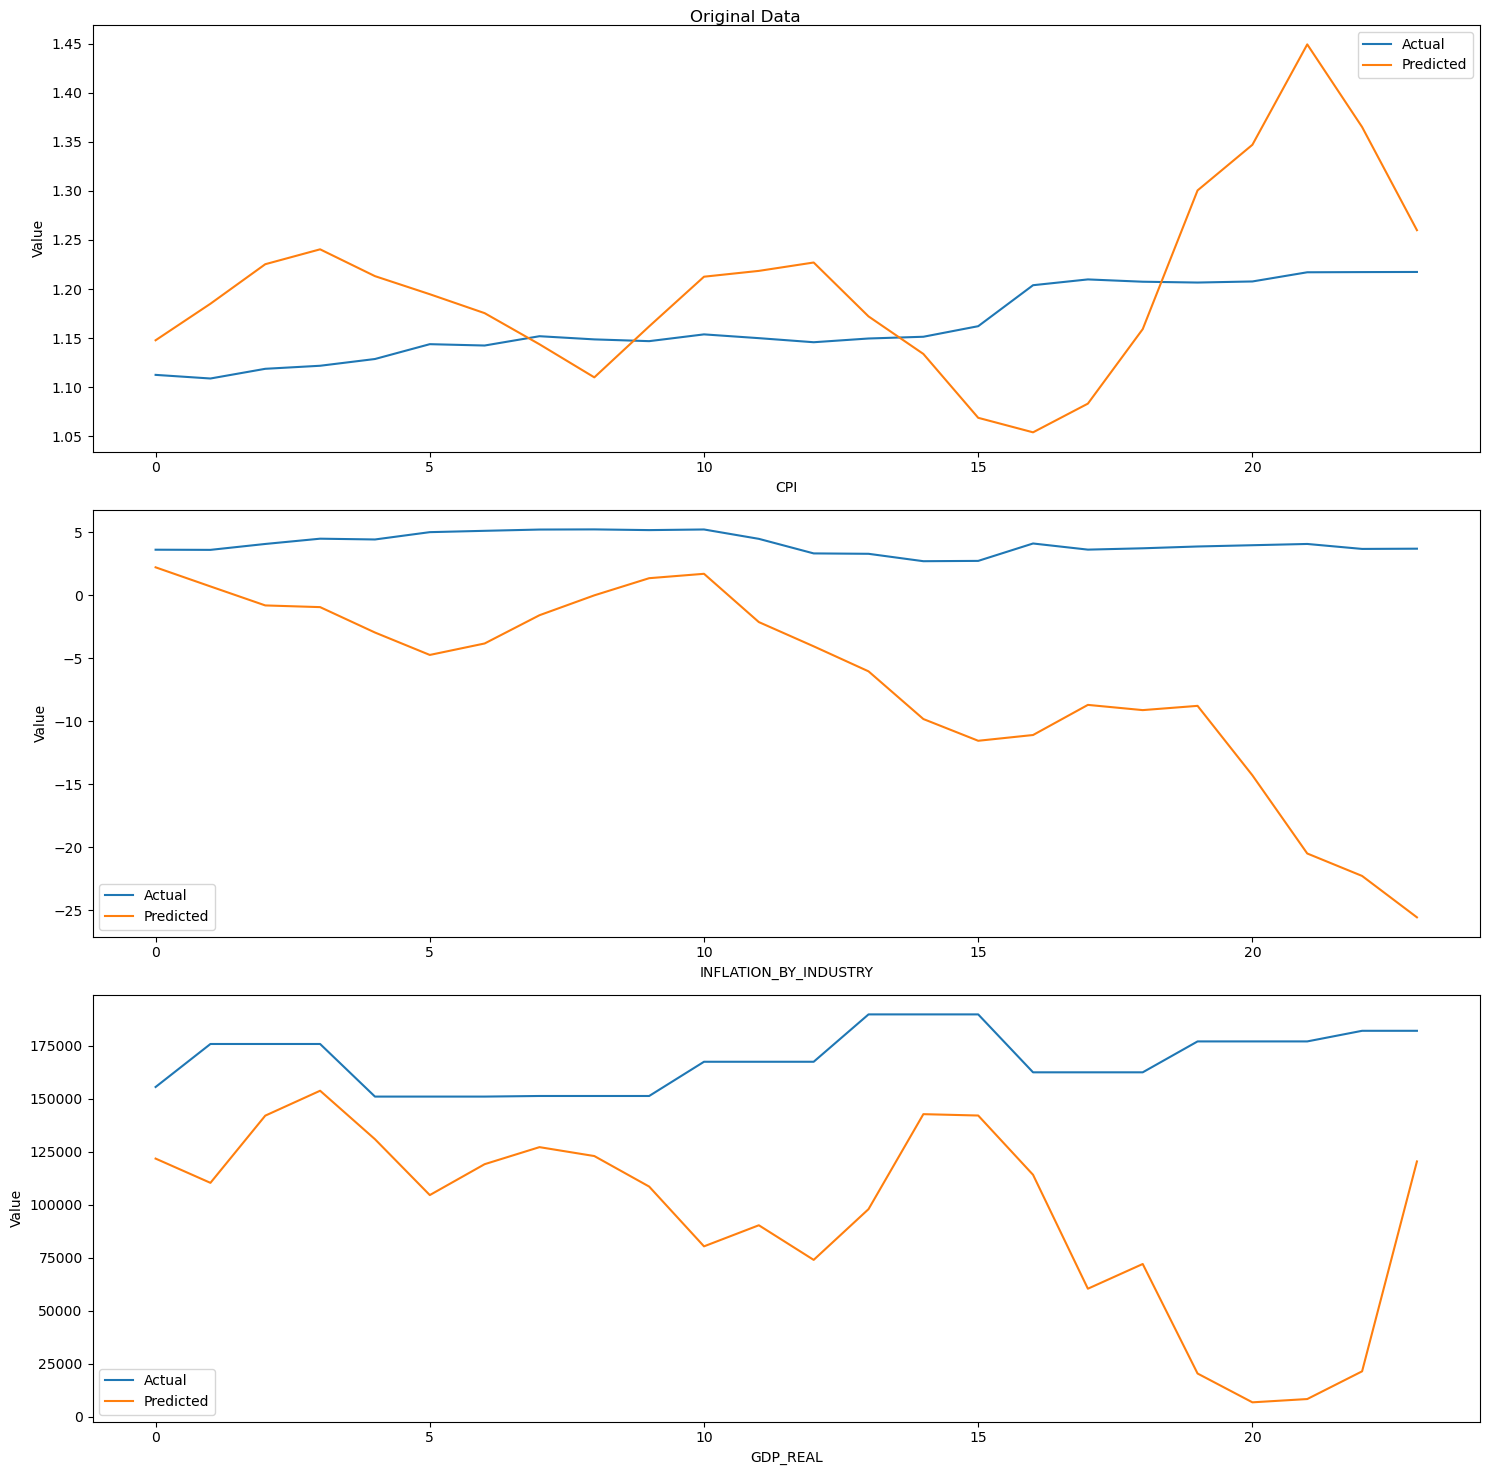

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 13
Column CPI - MSE: 0.015269932607121619, RMSE: 0.12357156876531761, MAE: 0.09230621748710177
Column INFLATION_BY_INDUSTRY - MSE: 99.17649938486477, RMSE: 9.958739849241207, MAE: 6.982542202663488
Column GDP_REAL - MSE: 5470417703.380004, RMSE: 73962.27216209628, MAE: 47264.79762537151


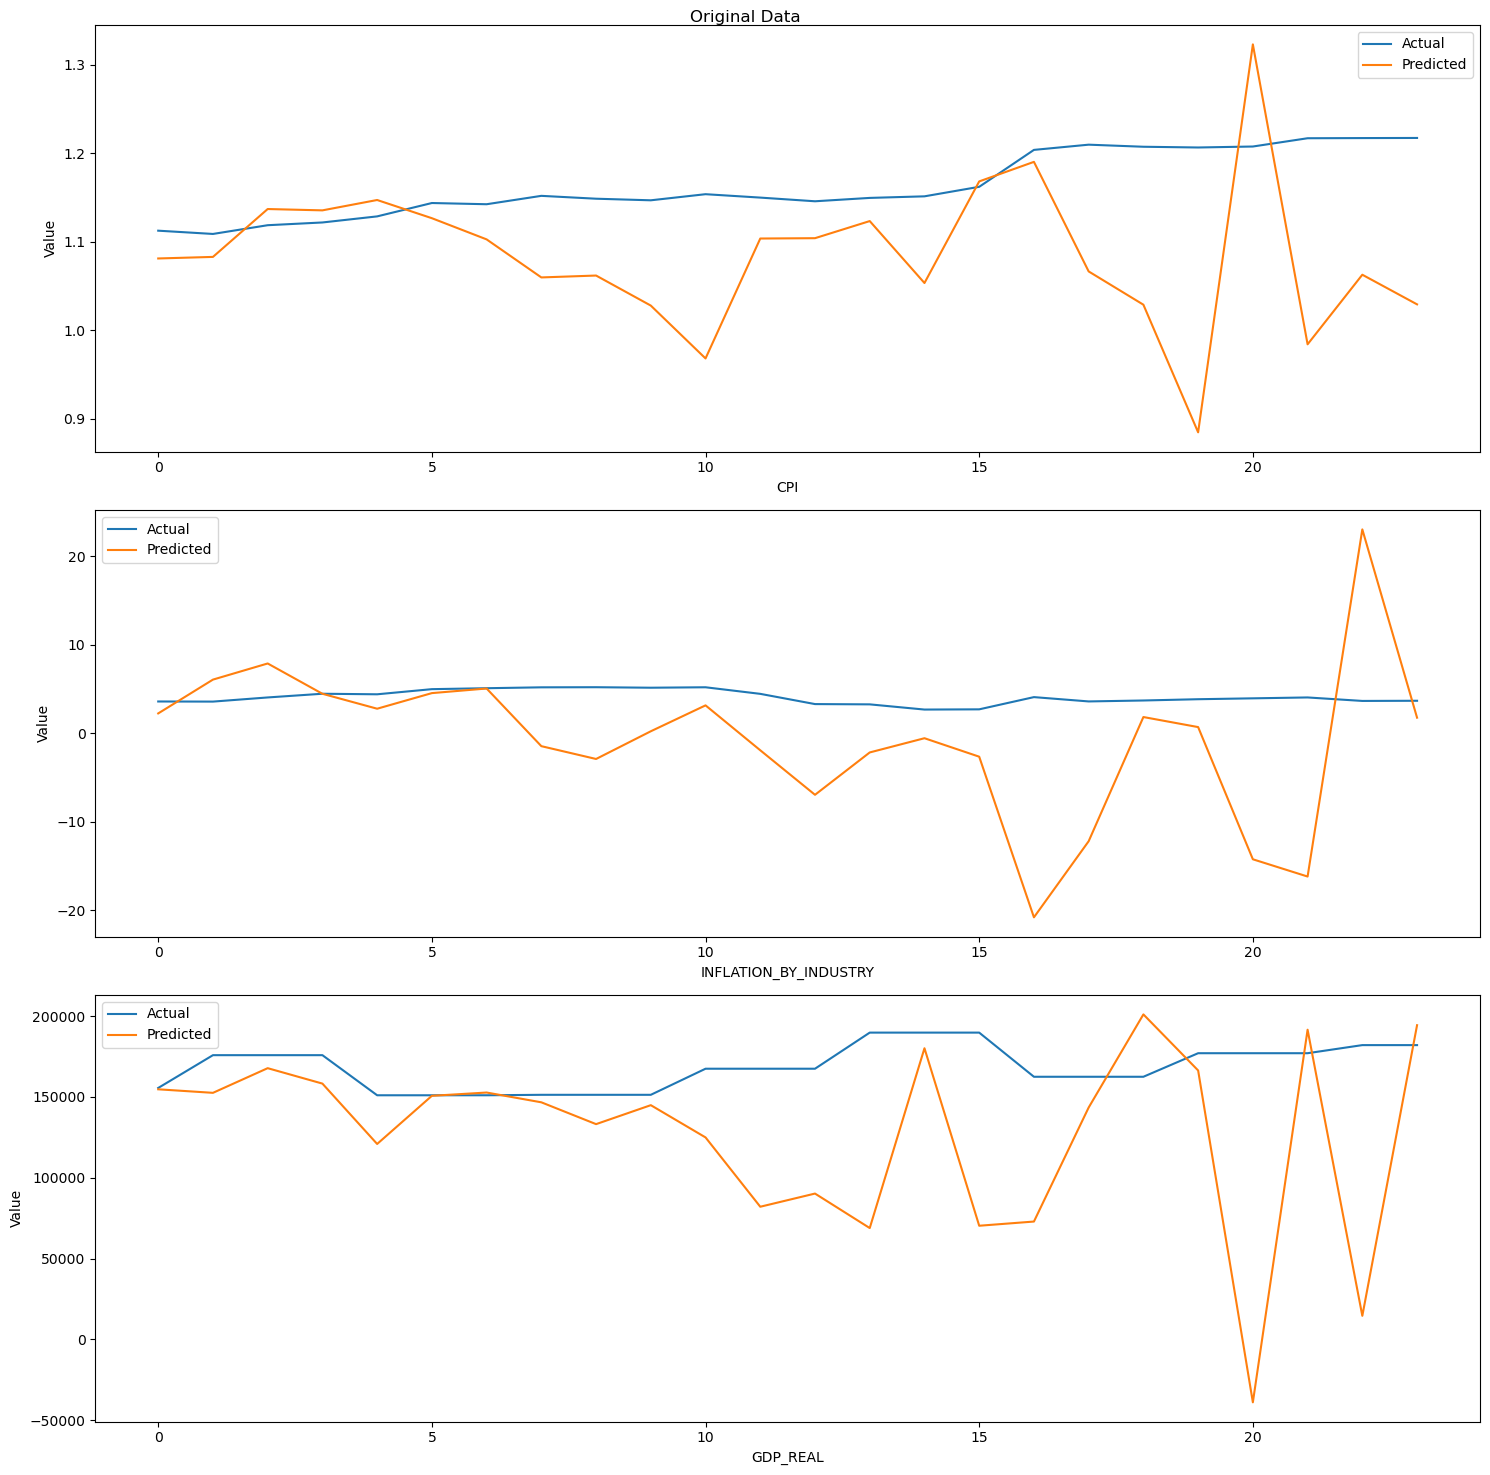

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 14
Column CPI - MSE: 0.014974326859154013, RMSE: 0.12236963209536103, MAE: 0.08971124173544408
Column INFLATION_BY_INDUSTRY - MSE: 99.12995597699603, RMSE: 9.956402762895644, MAE: 7.4666747072609
Column GDP_REAL - MSE: 28357526941.6935, RMSE: 168396.93269680865, MAE: 134049.29479877345


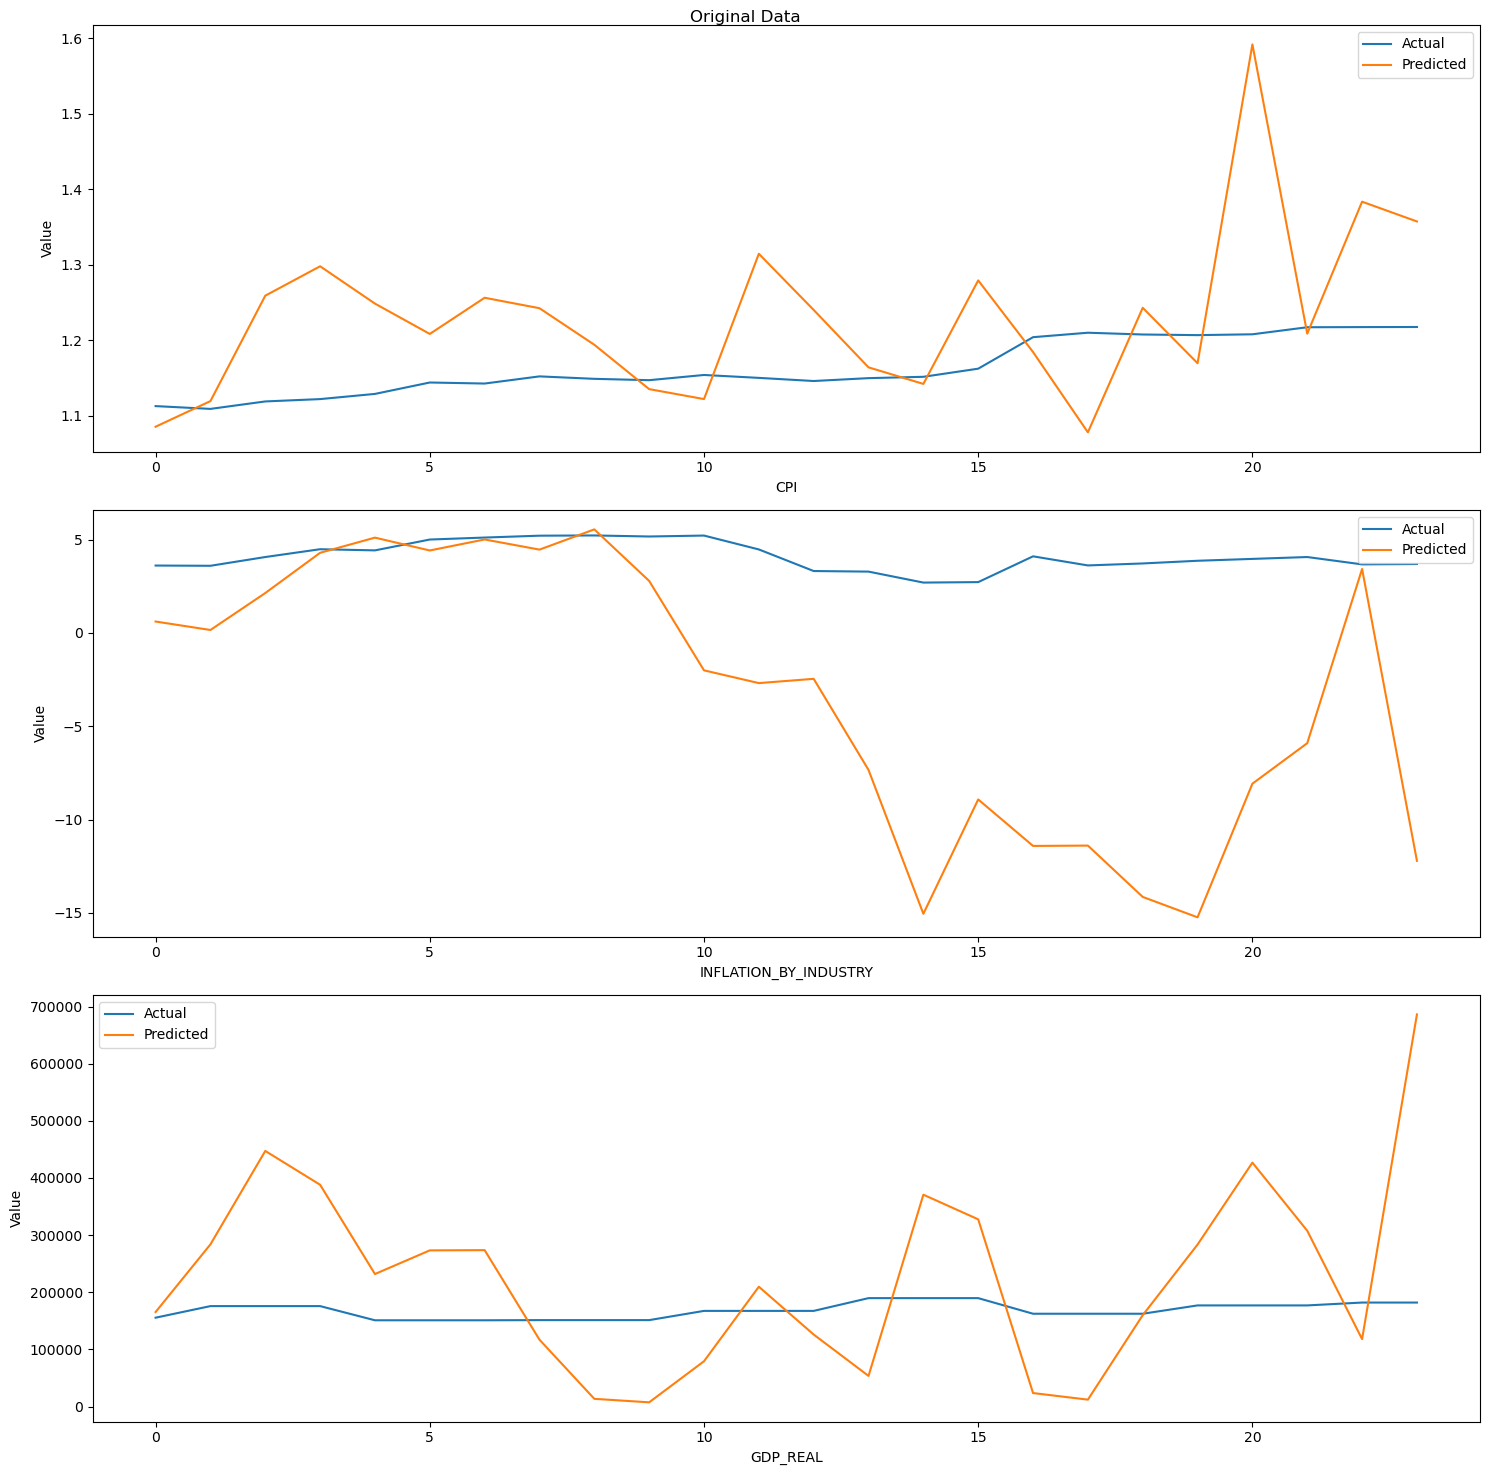

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 15
Column CPI - MSE: 0.28995734304292026, RMSE: 0.5384768732665501, MAE: 0.40039601850960355
Column INFLATION_BY_INDUSTRY - MSE: 2155.875942584044, RMSE: 46.43141116296213, MAE: 31.773715325130798
Column GDP_REAL - MSE: 3687808252570.078, RMSE: 1920366.6974226767, MAE: 1532481.4226212837


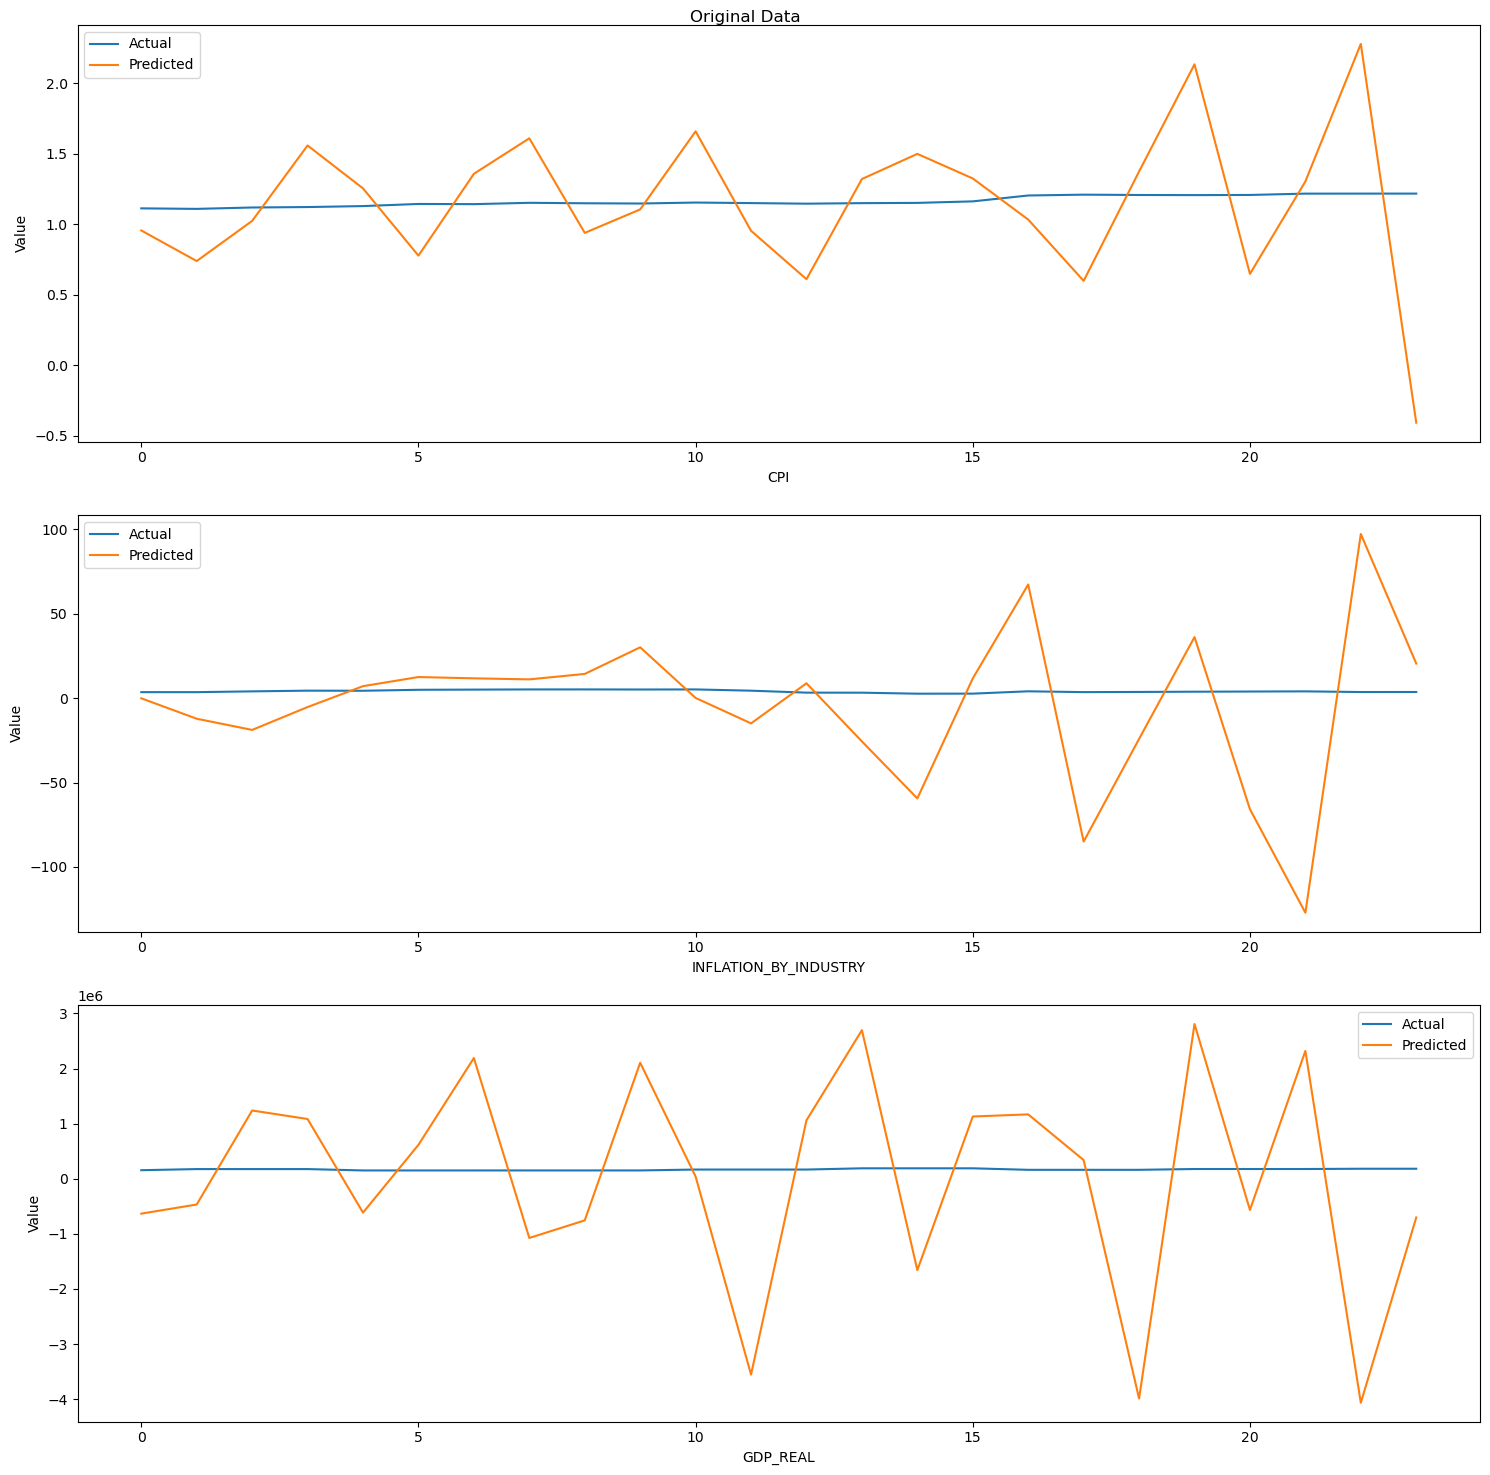

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 16
Column CPI - MSE: 68.34091134626176, RMSE: 8.266856194845884, MAE: 6.225799214882113
Column INFLATION_BY_INDUSTRY - MSE: 250150.88659799137, RMSE: 500.1508638380937, MAE: 410.55771336028664
Column GDP_REAL - MSE: 1.3017523933125616e+16, RMSE: 114094364.16022317, MAE: 61106507.10500443


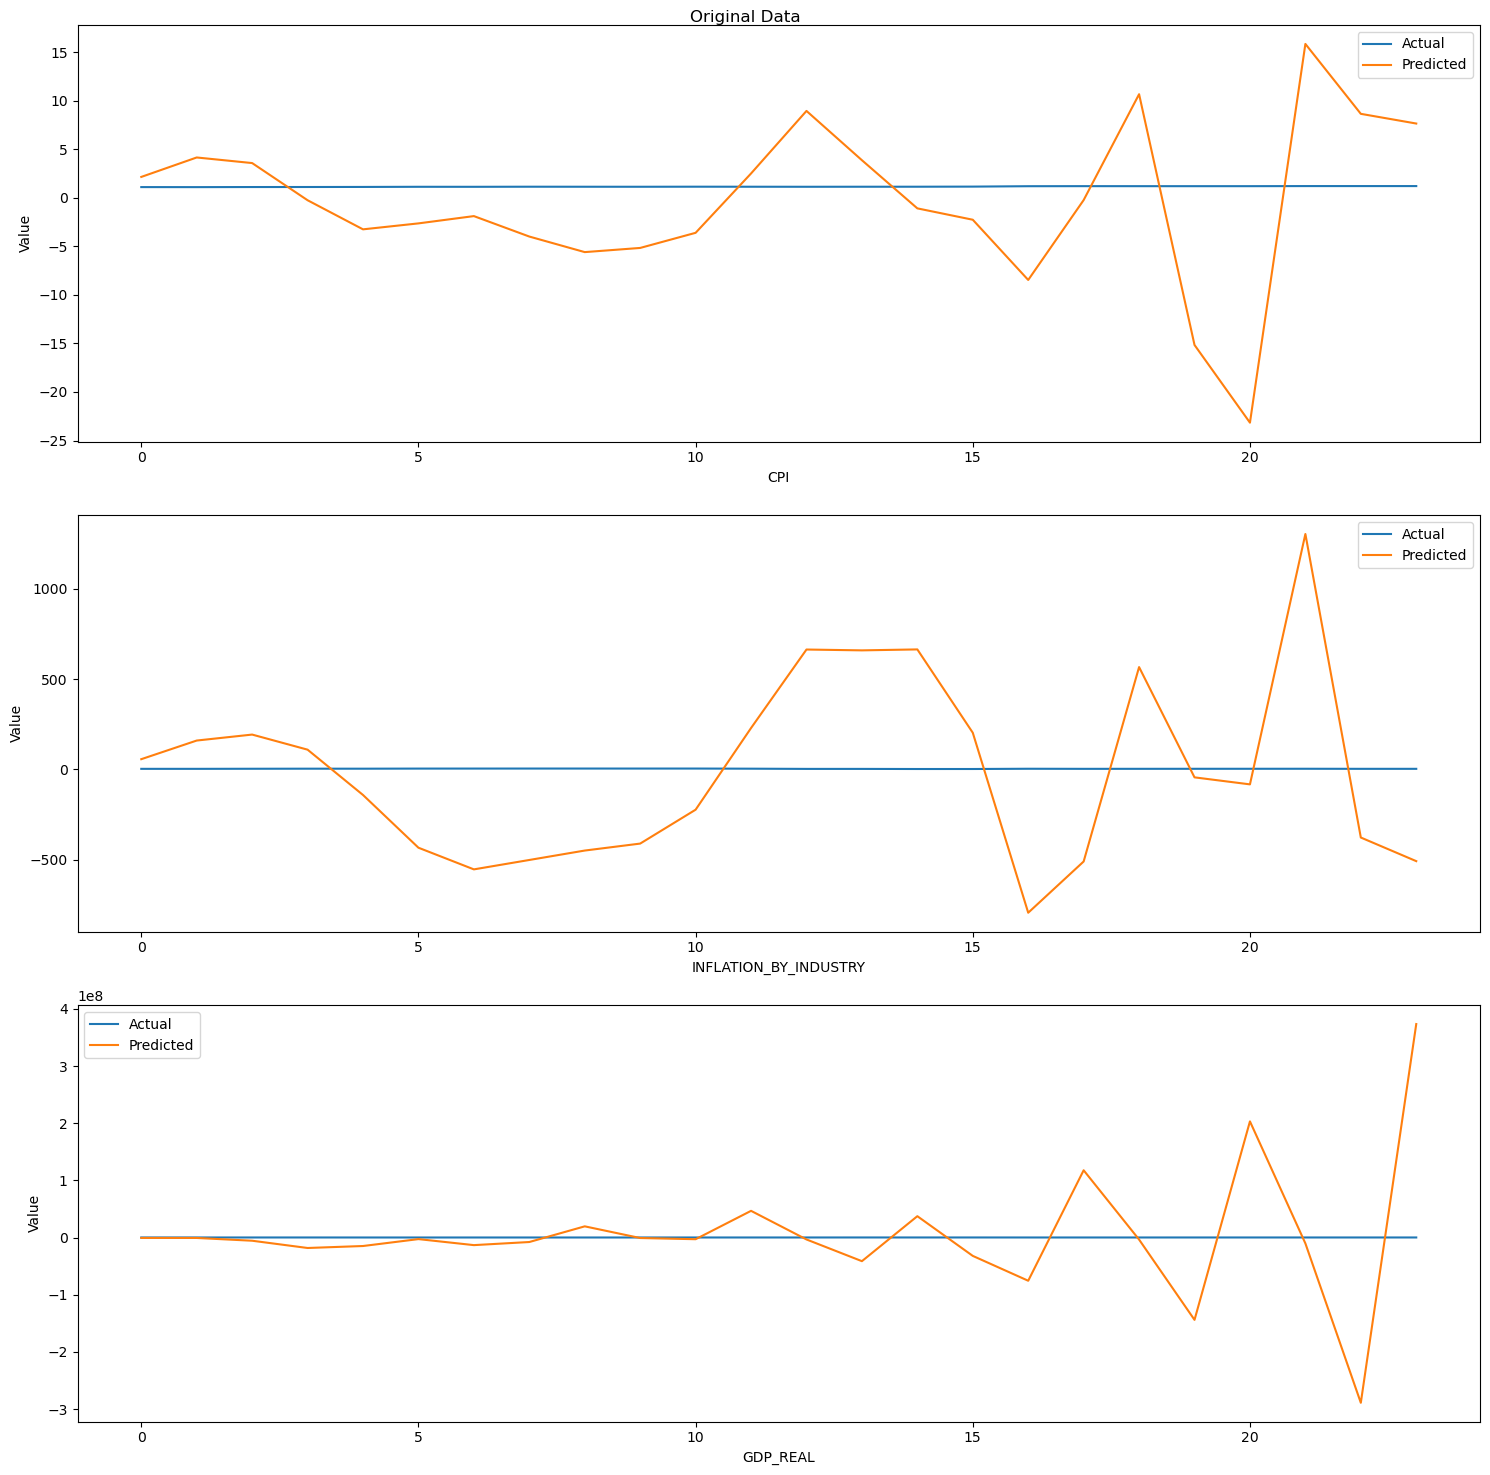

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 17
Column CPI - MSE: 1.6375732973214976, RMSE: 1.2796770285198908, MAE: 1.0274689162828137
Column INFLATION_BY_INDUSTRY - MSE: 11288.875908428074, RMSE: 106.2491219183861, MAE: 87.9200681324149
Column GDP_REAL - MSE: 11038325464617.5, RMSE: 3322397.5476480084, MAE: 2657143.451888822


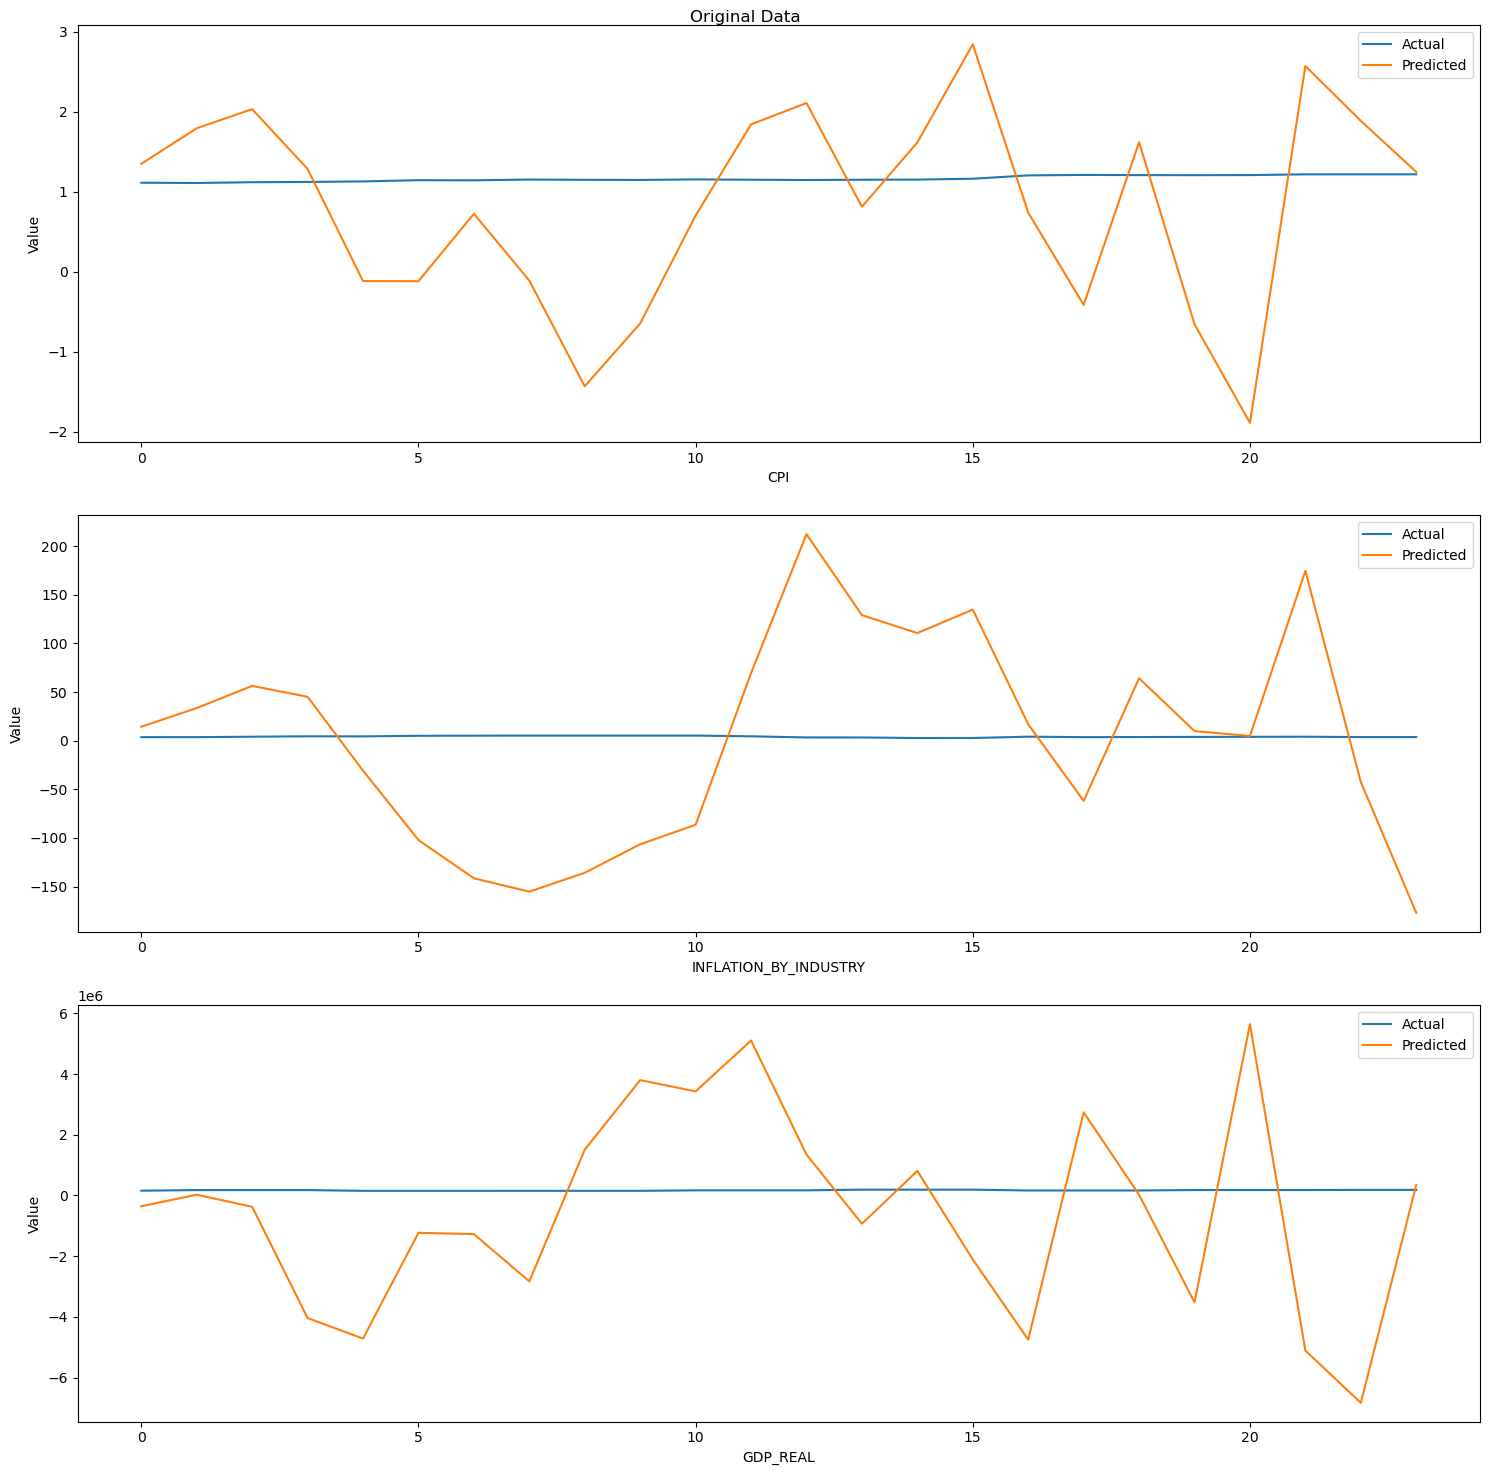

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 18
Column CPI - MSE: 7.309459588418844, RMSE: 2.703601225850226, MAE: 2.2135989110004255
Column INFLATION_BY_INDUSTRY - MSE: 31518.736508966842, RMSE: 177.53516978043208, MAE: 133.5888187957568
Column GDP_REAL - MSE: 79961201614657.86, RMSE: 8942102.751291659, MAE: 6620335.532647829


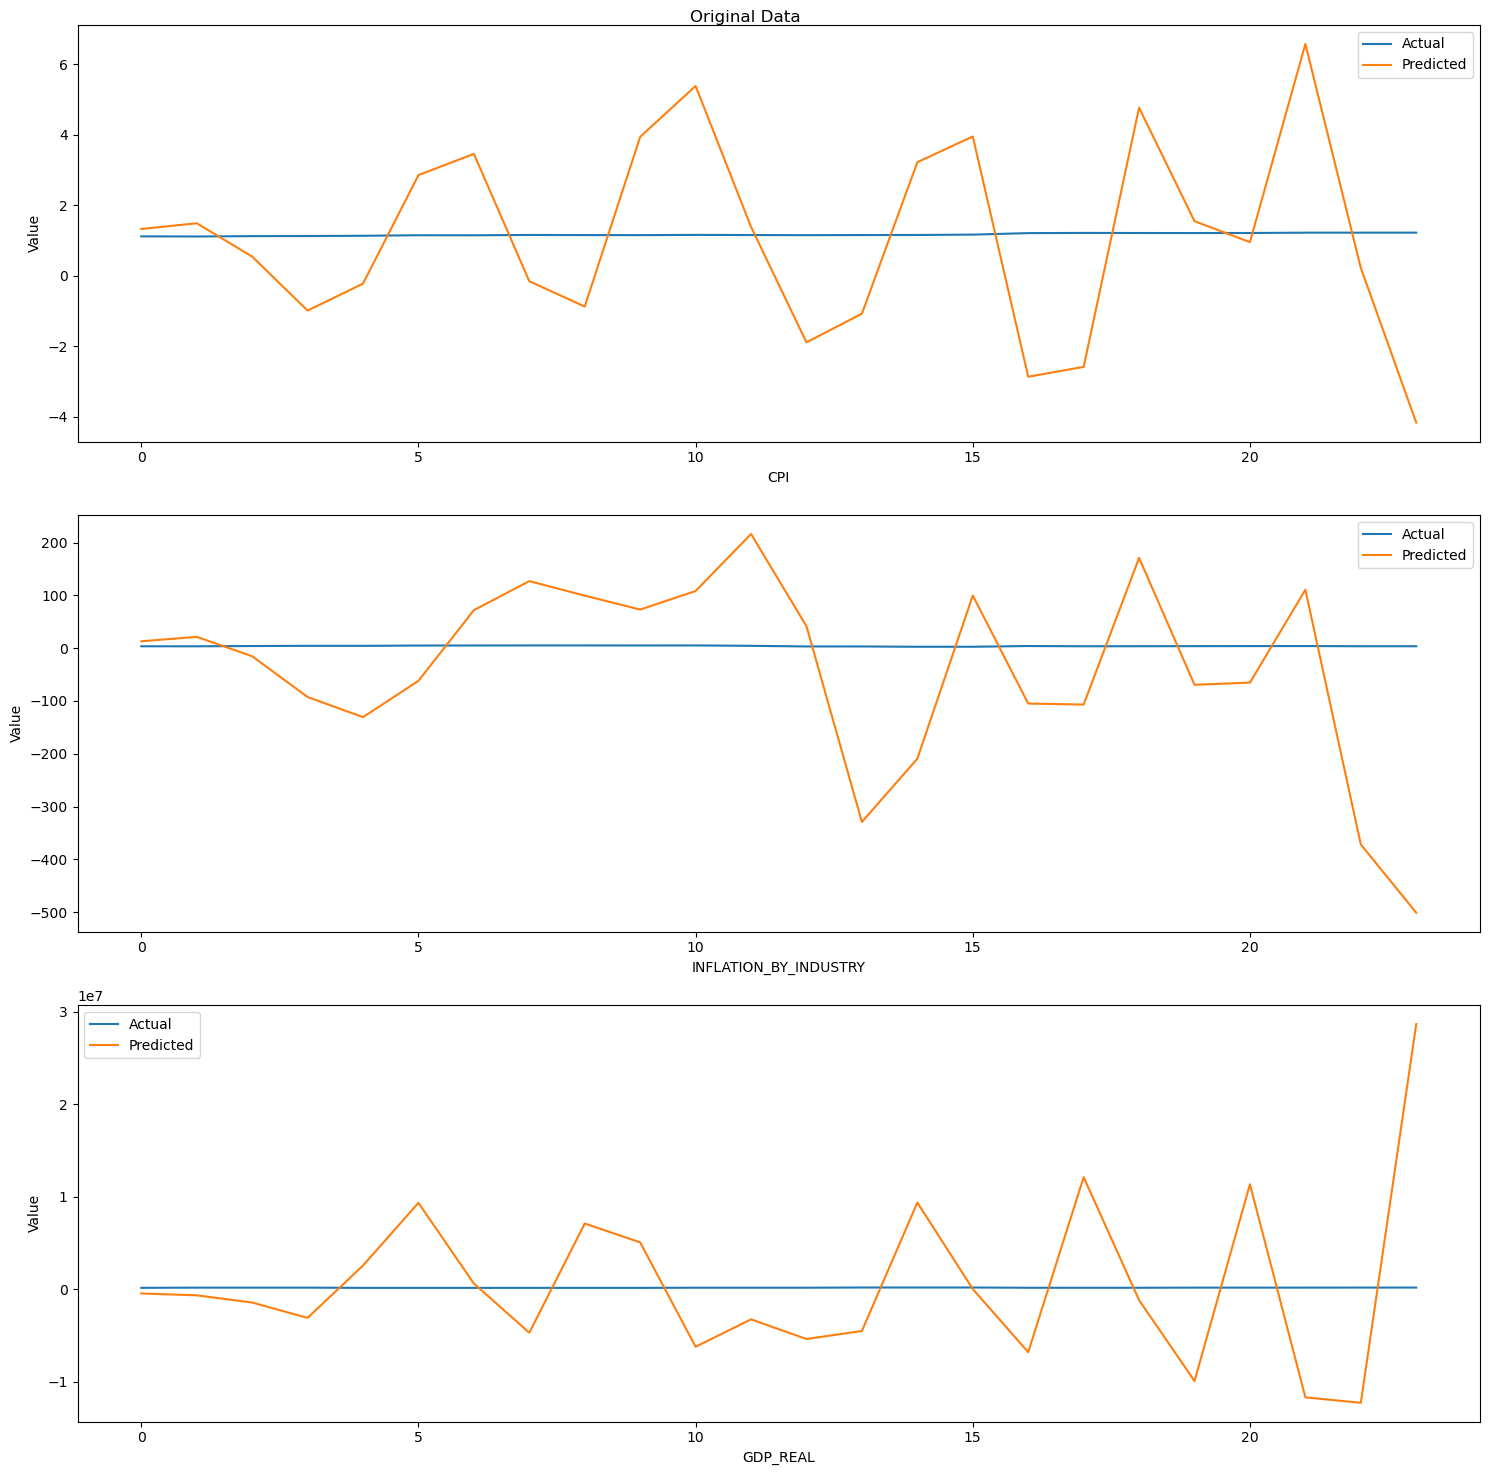

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 19
Column CPI - MSE: 8.062054127126801, RMSE: 2.83937565797955, MAE: 2.0355859002832575
Column INFLATION_BY_INDUSTRY - MSE: 41817.32694156142, RMSE: 204.492853032964, MAE: 156.0662157143607
Column GDP_REAL - MSE: 58663852625924.71, RMSE: 7659233.161741762, MAE: 5808169.072554237


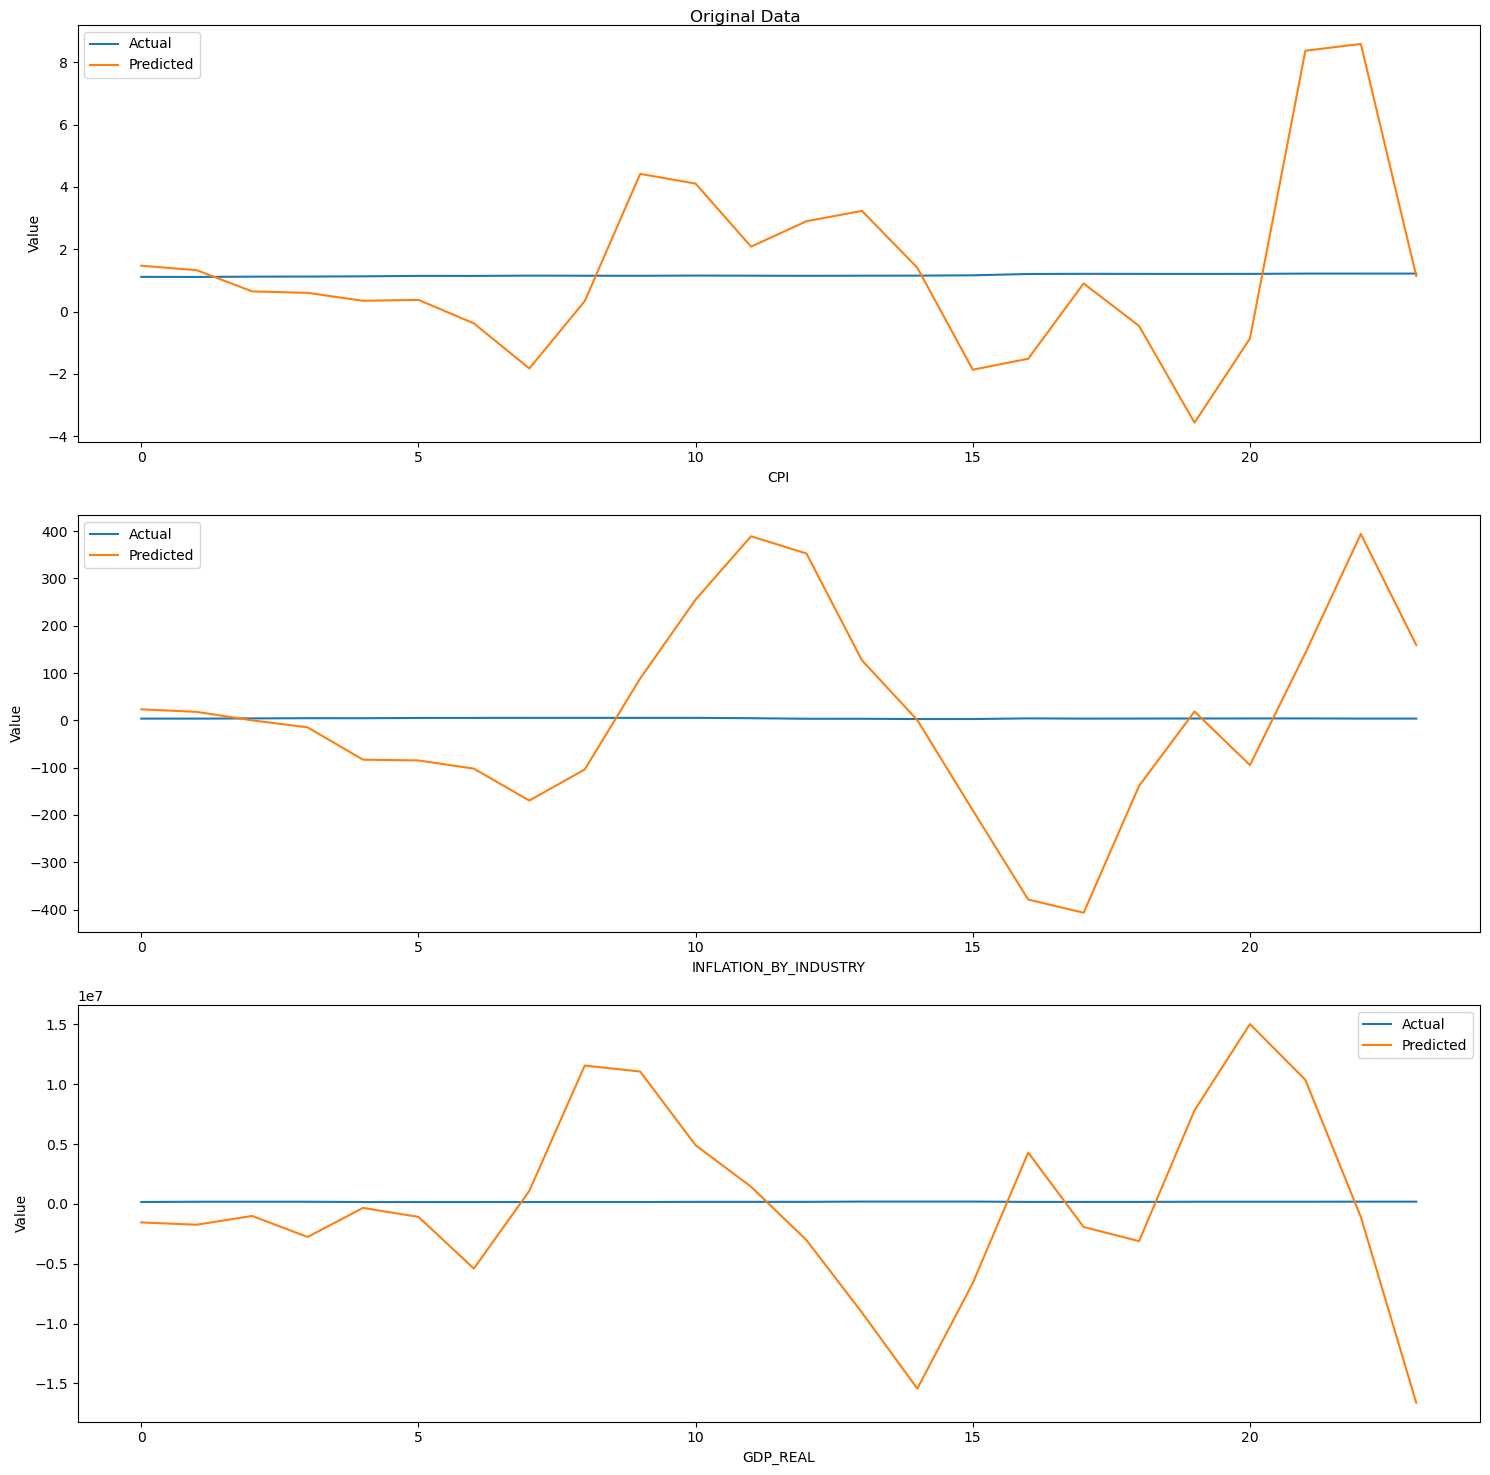

/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Lag: 20
Column CPI - MSE: 29.950748306959127, RMSE: 5.472727684341614, MAE: 4.216166485603828
Column INFLATION_BY_INDUSTRY - MSE: 236379.3026487298, RMSE: 486.18854639813327, MAE: 394.84555249747063
Column GDP_REAL - MSE: 241570094291128.5, RMSE: 15542525.351149617, MAE: 12693161.857252294


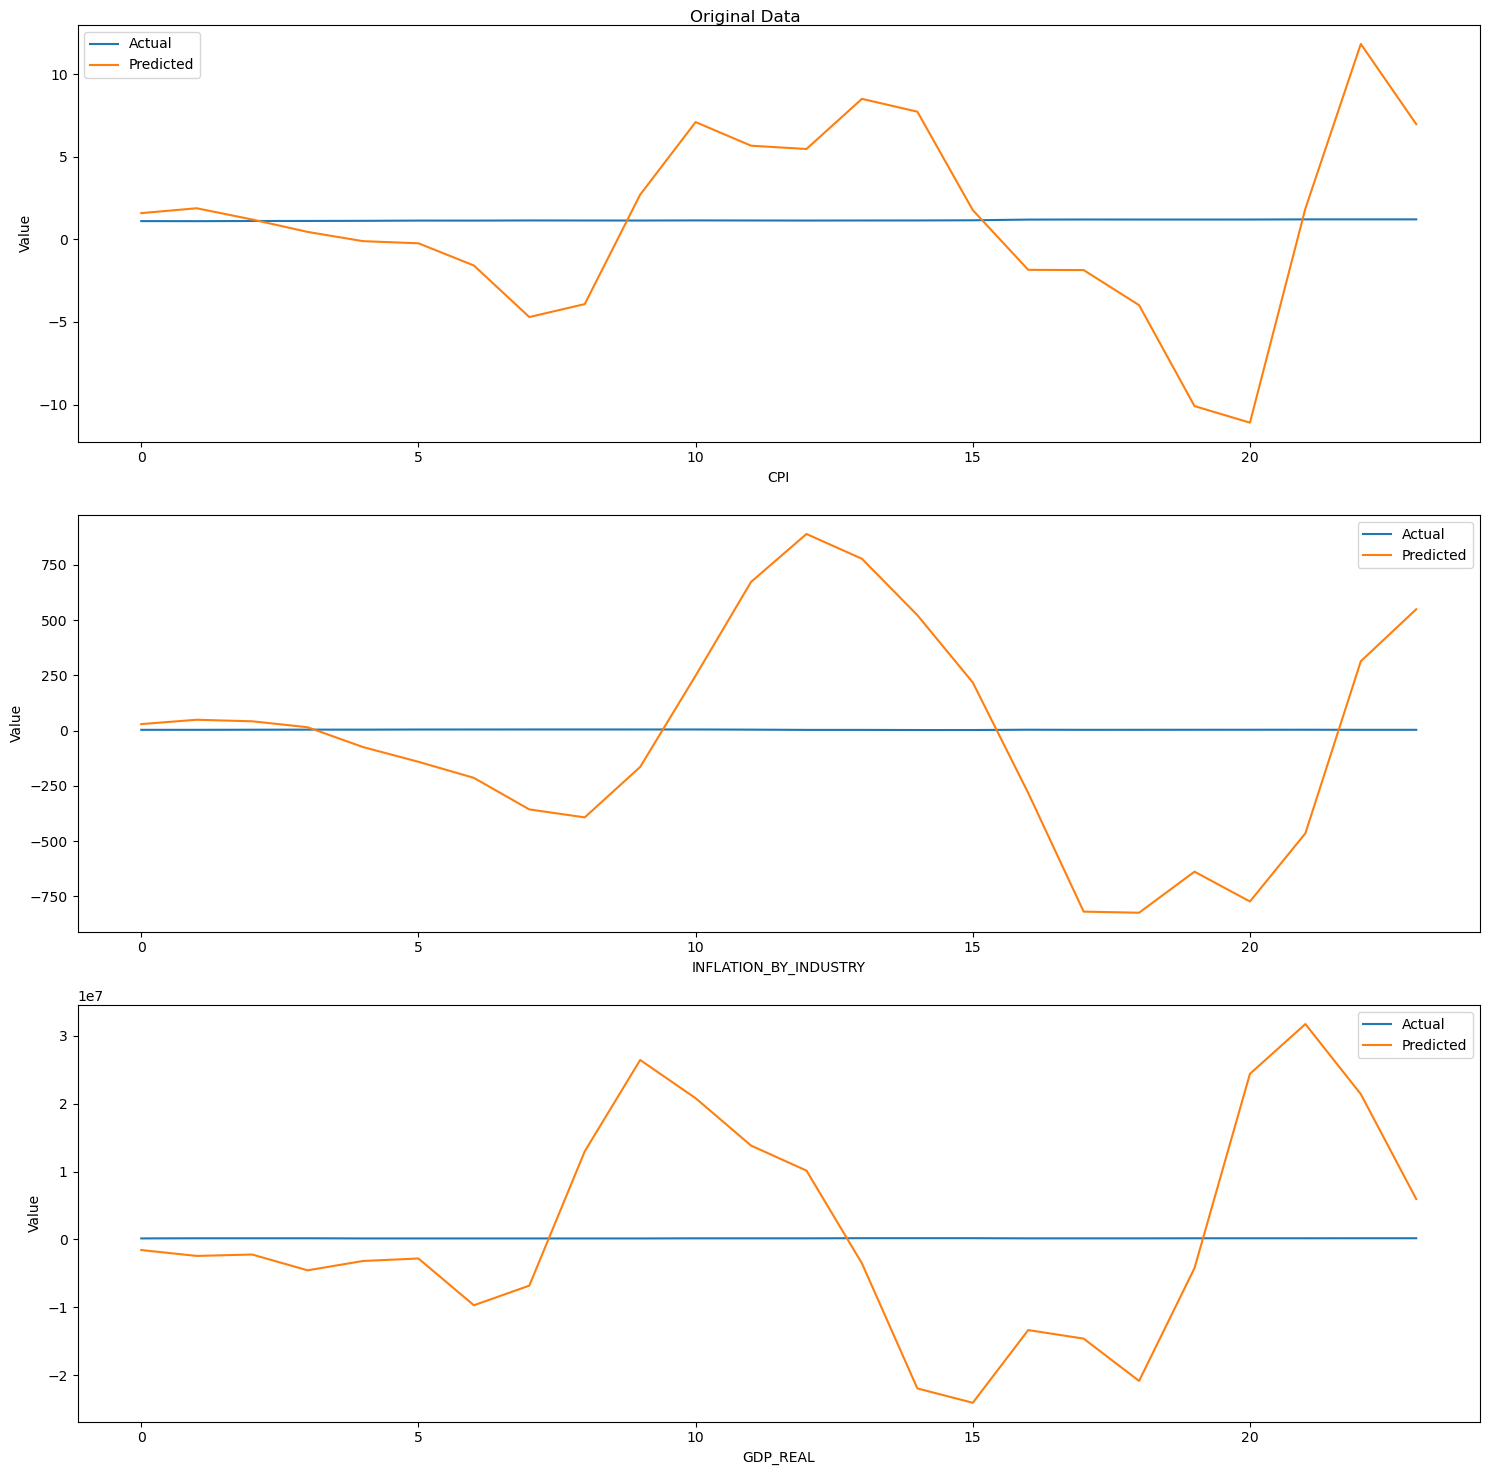

In [52]:
evaluation_results = []
for lag in range(1, 21):
    model = VAR(train_diff)
    fitted = model.fit(lag)

    last_two_scaled = scaled_train.iloc[-2:].values

    pred_VAR = fitted.forecast(train_diff.values[-lag:], steps=len(test_diff))
    pred_VAR_original = reverse_difference(last_two_scaled, pred_VAR, order=2)

    unscaled_VAR = unscale(pred_VAR_original)

    print(f'Lag: {lag}')
    # Evaluation by columns
    actual_original = test_data.iloc[:len(unscaled_VAR)].values  # Actual từ level gốc
    
    metrics = {}
    for i, col_name in enumerate(scaled_test.columns):
        mse = mean_squared_error(actual_original[:, i], unscaled_VAR[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(actual_original[:, i], unscaled_VAR[:, i])
        metrics[col_name] = {'MSE': mse, 'RMSE': rmse, 'MAE': mae}
        print(f'Column {col_name} - MSE: {mse}, RMSE: {rmse}, MAE: {mae}')

    total_mse = mean_squared_error(actual_original, unscaled_VAR)
    total_rmse = np.sqrt(total_mse)
    total_mae = mean_absolute_error(actual_original, unscaled_VAR)

    evaluation_results.append({
        'lag': lag,
        'MSE_CPI': metrics.get('CPI', {}).get('MSE'),
        'MSE_GDP_REAL': metrics.get('GDP_REAL', {}).get('MSE'),
        'MSE_INFLATION_BY_INDUSTRY': metrics.get('INFLATION_BY_INDUSTRY', {}).get('MSE'),
        'RMSE_CPI': metrics.get('CPI', {}).get('RMSE'),
        'RMSE_GDP_REAL': metrics.get('GDP_REAL', {}).get('RMSE'),
        'RMSE_INFLATION_BY_INDUSTRY': metrics.get('INFLATION_BY_INDUSTRY', {}).get('RMSE'),
        'MAE_CPI': metrics.get('CPI', {}).get('MAE'),
        'MAE_GDP_REAL': metrics.get('GDP_REAL', {}).get('MAE'),
        'MAE_INFLATION_BY_INDUSTRY': metrics.get('INFLATION_BY_INDUSTRY', {}).get('MAE'),
        'Total_MSE': total_mse,
        'Total_RMSE': total_rmse,
        'Total_MAE': total_mae
    })
    
    
    plt.figure(figsize=(15, 15))
    for i in range(no_columns):
        plt.subplot(no_columns, 1, i+1)
        plt.plot(actual_original[:, i], label='Actual')
        plt.plot(unscaled_VAR[:, i], label='Predicted')
        plt.title('')
        plt.xlabel(f'{scaled_test.columns[i]}')
        plt.ylabel('Value')
        plt.legend()
    plt.suptitle('Original Data')
    plt.tight_layout()
    plt.show()

In [53]:
# pd.set_option("display.float_format", lambda x: "%.0f" % x)

In [54]:
evaluation_results

[{'lag': 1,
  'MSE_CPI': 0.042264860520399655,
  'MSE_GDP_REAL': 1249340054.6216319,
  'MSE_INFLATION_BY_INDUSTRY': 21.50734630476792,
  'RMSE_CPI': 0.2055841932649484,
  'RMSE_GDP_REAL': 35346.00479009801,
  'RMSE_INFLATION_BY_INDUSTRY': 4.637601352506263,
  'MAE_CPI': 0.17715963291209982,
  'MAE_GDP_REAL': 27722.17221727132,
  'MAE_INFLATION_BY_INDUSTRY': 4.401740989444503,
  'Total_MSE': 416446692.057081,
  'Total_RMSE': 20407.025556339195,
  'Total_MAE': 9242.250372631226},
 {'lag': 2,
  'MSE_CPI': 0.008005920956404686,
  'MSE_GDP_REAL': 11161066554.78692,
  'MSE_INFLATION_BY_INDUSTRY': 130.90280129359837,
  'RMSE_CPI': 0.08947581213045616,
  'RMSE_GDP_REAL': 105645.94906945992,
  'RMSE_INFLATION_BY_INDUSTRY': 11.441276209129748,
  'MAE_CPI': 0.077029734006357,
  'MAE_GDP_REAL': 91335.98785459461,
  'MAE_INFLATION_BY_INDUSTRY': 10.46251176811631,
  'Total_MSE': 3720355561.899242,
  'Total_RMSE': 60994.71749175696,
  'Total_MAE': 30448.84246536558},
 {'lag': 3,
  'MSE_CPI': 0.031489

In [55]:
evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df

,lag,MSE_CPI,MSE_GDP_REAL,MSE_INFLATION_BY_INDUSTRY,RMSE_CPI,RMSE_GDP_REAL,RMSE_INFLATION_BY_INDUSTRY,MAE_CPI,MAE_GDP_REAL,MAE_INFLATION_BY_INDUSTRY,Total_MSE,Total_RMSE,Total_MAE
0,1,0.042265,1.249340e+09,21.507346,0.205584,3.534600e+04,4.637601,0.177160,2.772217e+04,4.401741,4.164467e+08,2.040703e+04,9.242250e+03
1,2,0.008006,1.116107e+10,130.902801,0.089476,1.056459e+05,11.441276,0.077030,9.133599e+04,10.462512,3.720356e+09,6.099472e+04,3.044884e+04
2,3,0.031489,1.020470e+10,200.903449,0.177452,1.010183e+05,14.174041,0.154823,8.821813e+04,12.767212,3.401566e+09,5.832294e+04,2.941035e+04
3,4,0.008764,1.413426e+10,405.205181,0.093617,1.188876e+05,20.129709,0.082302,1.049264e+05,18.058868,4.711420e+09,6.863978e+04,3.498152e+04
4,5,0.005821,1.215809e+10,437.981839,0.076294,1.102637e+05,20.928016,0.067882,9.880680e+04,18.739519,4.052698e+09,6.366080e+04,3.294187e+04
5,6,0.010444,3.568616e+10,412.678390,0.102196,1.889078e+05,20.314487,0.091678,1.698096e+05,18.193575,1.189539e+10,1.090660e+05,5.660929e+04
6,7,0.009905,1.016752e+10,70.050676,0.099523,1.008341e+05,8.369628,0.088406,8.985875e+04,7.374123,3.389174e+09,5.821662e+04,2.995541e+04
7,8,0.006944,4.395240e+09,91.237813,0.083330,6.629661e+04,9.551849,0.072327,5.799396e+04,8.365386,1.465080e+09,3.827636e+04,1.933413e+04
8,9,0.002023,7.266088e+09,64.392856,0.044977,8.524135e+04,8.024516,0.038180,7.508558e+04,6.888440,2.422029e+09,4.921412e+04,2.503084e+04
9,10,0.001026,2.267074e+09,33.545358,0.032035,4.761380e+04,5.791835,0.026596,3.910312e+04,4.945647,7.556912e+08,2.748984e+04,1.303603e+04


# Chọn p = 10

In [56]:
lag = 10

model = VAR(train_diff)
fitted = model.fit(lag)

last_two_scaled = scaled_train.iloc[-2:].values

pred_VAR = fitted.forecast(train_diff.values[-lag:], steps=len(test_diff))
pred_VAR_original = reverse_difference(last_two_scaled, pred_VAR, order=2)

unscaled_VAR = unscale(pred_VAR_original)

print(f'Lag: {lag}')
# Evaluation by columns
actual_original = test_data.iloc[:len(unscaled_VAR)].values  # Actual từ level gốc

Lag: 10


/opt/conda/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [57]:
from pathlib import Path
import pandas as pd

# ===== TEST ACTUAL =====
actual_wide = pd.concat(
    [test_dates.iloc[:len(actual_original)].reset_index(drop=True),
     pd.DataFrame(actual_original, columns=train_data.columns)],
    axis=1
)

actual_long = actual_wide.melt(
    id_vars=['full_date'],
    var_name='indicator_code',
    value_name='value'
)
actual_long['series'] = 'actual'

# ===== FORECAST =====
forecast_wide = pd.concat(
    [test_dates.iloc[:len(unscaled_VAR)].reset_index(drop=True),
     pd.DataFrame(unscaled_VAR, columns=train_data.columns)],
    axis=1
)

forecast_long = forecast_wide.melt(
    id_vars=['full_date'],
    var_name='indicator_code',
    value_name='value'
)
forecast_long['series'] = 'forecast'

# ===== MERGE ALL =====
superset_df = pd.concat(
    [actual_long, forecast_long],
    ignore_index=True
)

superset_df = superset_df.sort_values(
    ['indicator_code', 'full_date', 'series']
).reset_index(drop=True)

superset_df

,full_date,indicator_code,value,series
0,2023-09-01,CPI,1.112547,actual
1,2023-09-01,CPI,1.124336,forecast
2,2023-10-01,CPI,1.108852,actual
3,2023-10-01,CPI,1.147870,forecast
4,2023-11-01,CPI,1.118731,actual
...,...,...,...,...
139,2025-06-01,INFLATION_BY_INDUSTRY,-2.068649,forecast
140,2025-07-01,INFLATION_BY_INDUSTRY,3.668750,actual
141,2025-07-01,INFLATION_BY_INDUSTRY,-2.691275,forecast
142,2025-08-01,INFLATION_BY_INDUSTRY,3.687500,actual


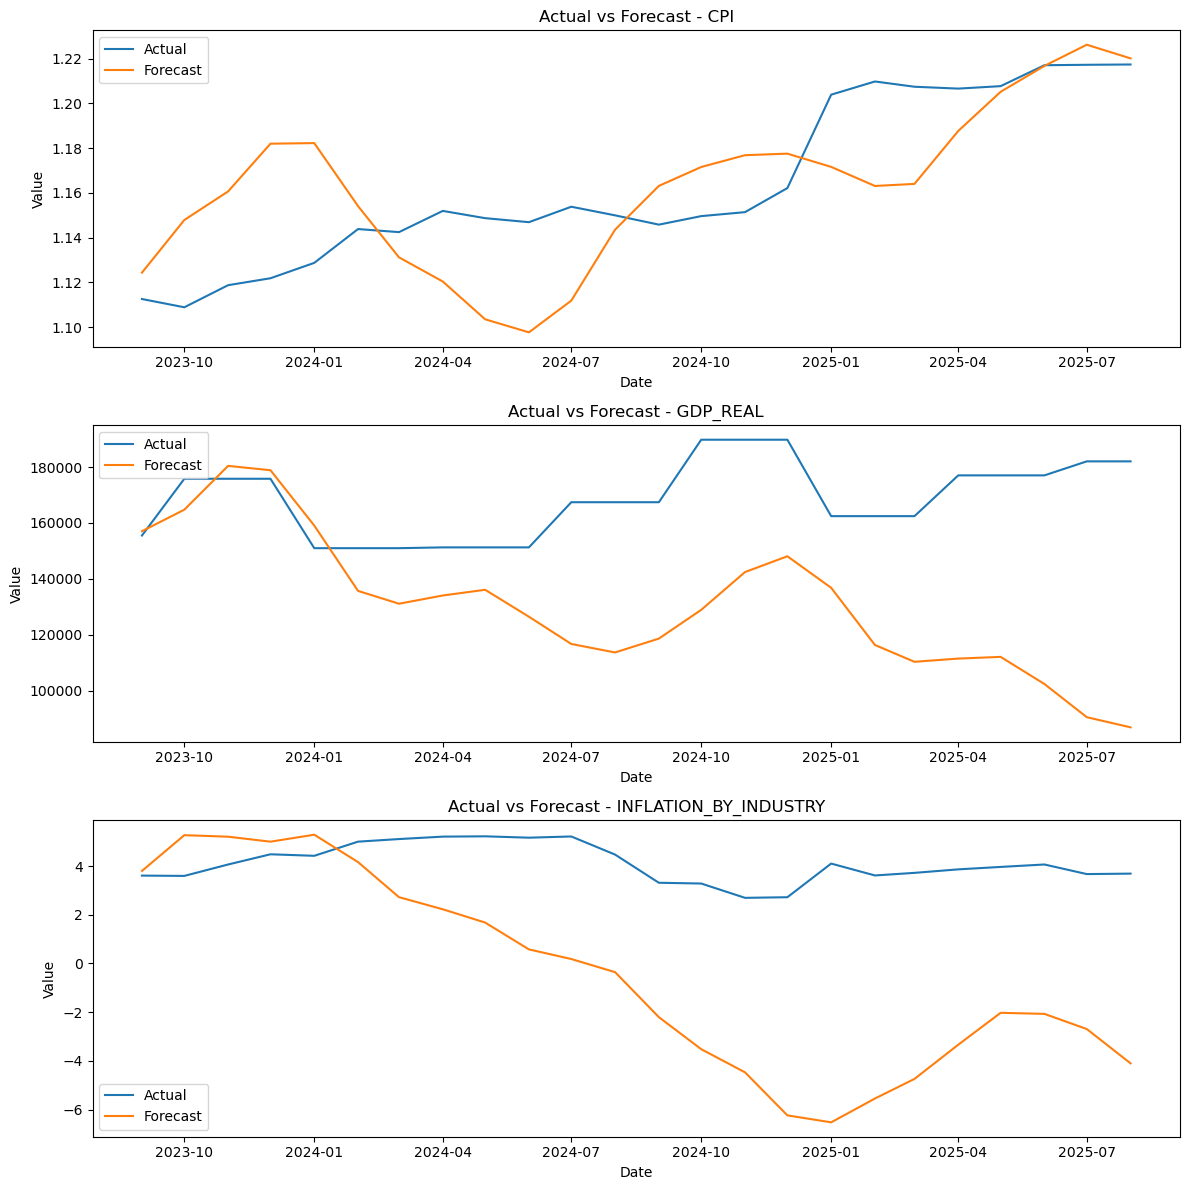

In [58]:
indicators = superset_df['indicator_code'].unique()

plt.figure(figsize=(12, 4 * len(indicators)))

for idx, ind in enumerate(indicators, start=1):
    df_ind = superset_df[superset_df['indicator_code'] == ind].copy()
    df_ind = df_ind.sort_values('full_date')

    # tách actual/forecast
    df_actual = df_ind[df_ind['series'] == 'actual']
    df_fore   = df_ind[df_ind['series'] == 'forecast']

    ax = plt.subplot(len(indicators), 1, idx)
    ax.plot(df_actual['full_date'], df_actual['value'], label='Actual')
    ax.plot(df_fore['full_date'], df_fore['value'], label='Forecast')

    ax.set_title(f'Actual vs Forecast - {ind}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Value')
    ax.legend()

plt.tight_layout()
plt.show()

In [59]:
# Write to Iceberg
fact_macro_var_forecast = spark.createDataFrame(superset_df)
fact_macro_var_forecast.write.format("iceberg").mode("overwrite").saveAsTable("nessie.gold.fact_macro_var_forecast")